<a href="https://colab.research.google.com/github/HanineAttia/Churn-Prediction-of-ooredoo-clients/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
365*5.5


2007.5

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # Reproducibility

n = 500_000  # Number of records

# 1. subscriber_id
subscriber_id = np.arange(1, n + 1)

# 2. subscriber_activation_date (random dates over last 5 years)
activation_dates = pd.to_datetime('2019-01-01') + pd.to_timedelta(np.random.randint(0, 2340, size=n), unit='D')
activation_dates = pd.Series(activation_dates)
activation_dates[np.random.choice(n, size=int(0.065 * n), replace=False)] = pd.NaT

# 3. offer_type
offer_type = np.random.choice(['Prepaid', 'Postpaid'], size=n, p=[0.9, 0.1])

# 4. nom_gouv with real distribution
gov_pop = {
    'Tunis': 1075306, 'Sfax': 1047468, 'Nabeul': 863172, 'Sousse': 762281,
    'Ben Arous': 722828, 'Ariana': 668552, 'Monastir': 599769, 'Kairouan': 600803,
    'Bizerte': 607388, 'Medenine': 537255, 'Gabès': 410847, 'Jendouba': 404352,
    'Béja': 311417, 'Kef': 237686, 'Siliana': 216242, 'Zaghouan': 201065,
    'Mahdia': 449985, 'Kasserine': 492741, 'Sidi Bouzid': 489991, 'Gafsa': 388776,
    'Tozeur': 120036, 'Tataouine': 162654, 'Kébili': 183201, 'Other': 0
}
govs = list(gov_pop.keys())
gov_probs = np.array(list(gov_pop.values()), dtype=float)
gov_probs /= gov_probs.sum()

nom_gouv = np.random.choice(govs, size=n, p=gov_probs)
nom_gouv[np.random.choice(n, size=int(0.01 * n), replace=False)] = np.nan

# 5. customer_type
customer_type = np.random.choice(['B2C', 'B2B'], size=n, p=[0.9, 0.1])

# 6. flag_aon
flag_aon = np.random.choice([1, 2], size=n, p=[0.8, 0.2])
flag_app_user = np.random.choice([0, 1, np.nan], size=n, p=[0.7, 0.1, 0.2])

# 7. gender
gender = np.random.choice(['M', 'F'], size=n)
gender[np.random.choice(n, size=int(0.08 * n), replace=False)] = np.nan

# 8. nationality
nationality = np.random.choice(['Tunisian', 'Foreigner'], size=n, p=[0.95, 0.05])
nationality[np.random.choice(n, size=int(0.05 * n), replace=False)] = np.nan

# 9. date_of_birth (age 18-70)
years = np.random.randint(1954, 2006, size=n)
months = np.random.randint(1, 13, size=n)
days = np.random.randint(1, 29, size=n)
dob = pd.to_datetime(dict(year=years, month=months, day=days))
dob = pd.Series(dob)
dob[np.random.choice(n, size=int(0.015 * n), replace=False)] = pd.NaT

# 10. marital_status
marital_status = np.random.choice(['Single', 'Married', ''], size=n)
marital_status[np.random.choice(n, size=int(0.175 * n), replace=False)] = np.nan

# 11. revenue_202505 with tuned distribution
revenue_202505 = np.round(np.random.exponential(scale=20, size=n), 2)
revenue_202505 = pd.Series(revenue_202505)

# 12-13. revenue breakdown
revenue_data_202505 = revenue_202505 * np.random.uniform(0.2, 0.6, size=n)
max_vas_possible = revenue_202505 - revenue_data_202505
max_vas_possible = np.clip(max_vas_possible, 0, None)
revenue_vas_202505 = max_vas_possible * np.random.uniform(0, 1, size=n)

revenue_data_202505 = np.round(revenue_data_202505, 2)
revenue_vas_202505 = np.round(revenue_vas_202505, 2)

# 14. vol_data_202505 (usage in GB) tuned
# 14. vol_data_202505 (usage in GB) tuned
vol_data_202505 = np.round(np.random.exponential(scale=3.5, size=n), 2)
vol_data_202505 = pd.Series(vol_data_202505)

# 15. mou_202505 (minutes) tuned
mou_202505 = np.round(np.random.exponential(scale=220, size=n), 2)
mou_202505 = pd.Series(mou_202505)


# 16-19 device indicators
smartphone_indicator = np.random.choice(['Yes', 'No'], size=n, p=[0.7, 0.3])
device_3g_indicator = np.random.choice(['Yes', 'No'], size=n, p=[0.6, 0.4])
ready_4g_indicator = np.random.choice(['Yes', 'No'], size=n, p=[0.6, 0.4])
ready_5g_indicator = np.random.choice(['Yes', 'No'], size=n, p=[0.2, 0.8])
ready_5g_indicator[np.random.choice(n, size=int(0.03 * n), replace=False)] = np.nan

# Introduce missing values
revenue_202505[np.random.choice(n, size=int(0.075 * n), replace=False)] = np.nan
revenue_data_202505[np.random.choice(n, size=int(0.245 * n), replace=False)] = np.nan
revenue_vas_202505[np.random.choice(n, size=int(0.42 * n), replace=False)] = np.nan
vol_data_202505[np.random.choice(n, size=int(0.26 * n), replace=False)] = np.nan
mou_202505[np.random.choice(n, size=int(0.15 * n), replace=False)] = np.nan

# 20. flag_churn tuned to ~7.5% churn
churn_prob = (
    0.05
    + 0.25 * pd.Series(revenue_202505 < 10).fillna(0).astype(float)
    + 0.15 * (activation_dates.isna() | (activation_dates > pd.to_datetime('2024-01-01')))
    + 0.20 * pd.Series(nationality == 'Foreigner').fillna(False).astype(float)
    + 0.20 * pd.Series(marital_status == 'Single').fillna(False).astype(float)
    + 0.20 * pd.Series(customer_type == 'B2C').fillna(False).astype(float)
    + 0.20 * pd.Series(gender == 'F').fillna(False).astype(float)
    - 0.1 * pd.Series(flag_app_user == 1).fillna(False).astype(float)
    - 0.06 * pd.Series(ready_4g_indicator == 'Yes').fillna(False).astype(float)
    + 0.08 * pd.Series(device_3g_indicator == 'Yes').fillna(False).astype(float)
    - 0.15 * pd.Series(ready_5g_indicator == 'Yes').fillna(False).astype(float)
    - 0.15 * pd.Series(smartphone_indicator == 'Yes').fillna(False).astype(float)
    + 0.20 * pd.Series(offer_type == 'Prepaid').fillna(False).astype(float)
        + 0.2 * pd.Series(nom_gouv == 'Monastir').fillna(False).astype(float)
     + 0.1 * pd.Series(nom_gouv == 'Mahdia').fillna(False).astype(float)
    + 0.16 * pd.Series(nom_gouv == 'Sousse').fillna(False).astype(float)
       - 0.16 * pd.Series(nom_gouv == 'Tunis').fillna(False).astype(float)
    - 0.12 * pd.Series(nom_gouv == 'Ariana').fillna(False).astype(float)
          - 0.06 * pd.Series(nom_gouv == 'Tataouine').fillna(False).astype(float)
    - 0.1 * pd.Series(nom_gouv == 'Kasserine').fillna(False).astype(float)
       + 0.2 * pd.Series(nom_gouv == 'Zaghouan').fillna(False).astype(float)
     + 0.1 * pd.Series(nom_gouv == 'Béja').fillna(False).astype(float)
    + 0.16 * pd.Series(nom_gouv == 'Gafsa').fillna(False).astype(float)
       - 0.16 * pd.Series(nom_gouv == 'Jendouba').fillna(False).astype(float)
    - 0.12 * pd.Series(nom_gouv == 'Nabeul').fillna(False).astype(float)
          - 0.06 * pd.Series(nom_gouv == 'Kef').fillna(False).astype(float)
    - 0.1 * pd.Series(nom_gouv == 'Sfax').fillna(False).astype(float)





)
churn_prob = np.clip(churn_prob, 0, 0.3)


flag_churn = (np.random.rand(n) < churn_prob).astype(int)

# 5% high revenue churners exception
churn_mask = flag_churn == 1
high_rev_exceptions = np.random.rand(n) < 0.05
reduction_factor_rev = np.random.uniform(0.3, 0.6, size=n)
reduction_factor_usage = np.random.uniform(0.3, 0.6, size=n)

revenue_202505.loc[churn_mask & ~high_rev_exceptions] *= reduction_factor_rev[churn_mask & ~high_rev_exceptions]
vol_data_202505.loc[churn_mask & ~high_rev_exceptions] *= reduction_factor_usage[churn_mask & ~high_rev_exceptions]
mou_202505.loc[churn_mask & ~high_rev_exceptions] *= reduction_factor_usage[churn_mask & ~high_rev_exceptions]

# 21. flag_app_user
flag_app_user = np.random.choice([0, 1, np.nan], size=n, p=[0.7, 0.1, 0.2])

# Final DataFrame
df_simulated1 = pd.DataFrame({
    'subscriber_id': subscriber_id,
    'subscriber_activation_date': activation_dates,
    'offer_type': offer_type,
    'nom_gouv': nom_gouv,
    'customer_type': customer_type,
    'flag_aon': flag_aon,
    'gender': gender,
    'nationality': nationality,
    'date_of_birth': dob,
    'marital_status': marital_status,
    'revenue_202505': revenue_202505,
    'revenue_data_202505': revenue_data_202505,
    'revenue_vas_202505': revenue_vas_202505,
    'vol_data_202505': vol_data_202505,
    'mou_202505': mou_202505,
    'smartphone_indicator': smartphone_indicator,
    'device_3g_indicator': device_3g_indicator,
    'ready_4g_indicator': ready_4g_indicator,
    'ready_5g_indicator': ready_5g_indicator,
    'flag_churn': flag_churn,
    'flag_app_user': flag_app_user
})

# Quick check
print(df_simulated1['flag_churn'].mean())
print(df_simulated1.head())


0.279112
   subscriber_id subscriber_activation_date offer_type     nom_gouv  \
0              1                 2021-05-10    Prepaid     Kairouan   
1              2                 2022-07-18    Prepaid          Kef   
2              3                        NaT    Prepaid        Gafsa   
3              4                 2021-12-31    Prepaid  Sidi Bouzid   
4              5                 2023-06-27    Prepaid         Sfax   

  customer_type  flag_aon gender nationality date_of_birth marital_status  \
0           B2C         1      F    Tunisian    1983-11-26                  
1           B2C         2      n    Tunisian    1987-02-13         Single   
2           B2C         1      F    Tunisian    1973-12-07         Single   
3           B2C         1      F         nan    1967-01-28                  
4           B2C         1      F    Tunisian    1983-05-27        Married   

   ...  revenue_data_202505  revenue_vas_202505  vol_data_202505  mou_202505  \
0  ...               

In [ ]:
df_simulated1

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,...,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user
0,1,2021-05-10,Prepaid,Kairouan,B2C,1,F,Tunisian,1983-11-26,,...,7.74,0.99,NaN,39.094801,Yes,Yes,No,No,1,0.0
1,2,2022-07-18,Prepaid,Kef,B2C,2,n,Tunisian,1987-02-13,Single,...,4.92,NaN,2.320000,305.460000,No,Yes,Yes,No,0,0.0
2,3,NaT,Prepaid,Gafsa,B2C,1,F,Tunisian,1973-12-07,Single,...,13.26,NaN,0.700346,16.889108,Yes,No,Yes,No,1,0.0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,1,F,nan,1967-01-28,,...,NaN,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0
4,5,2023-06-27,Prepaid,Sfax,B2C,1,F,Tunisian,1983-05-27,Married,...,NaN,0.32,NaN,97.880000,Yes,Yes,Yes,Yes,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,499996,2019-03-28,Postpaid,Bizerte,B2C,1,M,Tunisian,1992-12-05,Single,...,13.47,NaN,0.709184,86.479268,Yes,No,No,No,1,0.0
499996,499997,2022-01-27,Prepaid,Ben Arous,B2C,2,M,Tunisian,1981-04-09,nan,...,6.56,24.14,4.420000,105.870000,No,Yes,Yes,No,0,NaN
499997,499998,2024-01-19,Prepaid,nan,B2C,2,n,Tunisian,1971-04-24,Single,...,NaN,3.74,1.210000,66.370000,No,No,Yes,No,0,1.0
499998,499999,2019-07-05,Prepaid,Kasserine,B2C,1,M,Tunisian,1954-01-19,,...,6.70,NaN,0.060000,233.340000,No,Yes,Yes,No,0,0.0


In [ ]:
import pandas as pd
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#df_simulated1.to_csv('C:\\Users\\hanin\\OneDrive\\Desktop\\Hanine Attia\\projects\\projet churn\\simulated_churn_data.csv', index=False)

In [ ]:
from google.colab import files
data_to_load = files.upload()

Saving simulated_churn_data.csv to simulated_churn_data.csv


In [ ]:

data1= pd.read_csv(r'simulated_churn_data.csv')

In [ ]:
#data1= pd.read_csv(r'C:\\Users\\hanin\\OneDrive\\Desktop\\Hanine Attia\\projects\\projet churn\\simulated_churn_data.csv')

In [ ]:
data = data1.copy()

In [ ]:
data['nom_gouv'].value_counts()

,count
nom_gouv,
Tunis,46299
Sfax,45586
Nabeul,36755
Sousse,32555
Ben Arous,30635
Ariana,28497
Bizerte,26148
Monastir,25862
Kairouan,25631


In [ ]:
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user
0,1,2021-05-10,Prepaid,Kairouan,B2C,1,F,Tunisian,1983-11-26,NaN,10.037098,7.74,0.99,NaN,39.094801,Yes,Yes,No,No,1,0.0
1,2,2022-07-18,Prepaid,Kef,B2C,2,n,Tunisian,1987-02-13,Single,21.730000,4.92,NaN,2.320000,305.460000,No,Yes,Yes,No,0,0.0
2,3,NaN,Prepaid,Gafsa,B2C,1,F,Tunisian,1973-12-07,Single,14.460176,13.26,NaN,0.700346,16.889108,Yes,No,Yes,No,1,0.0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,1,F,NaN,1967-01-28,NaN,68.740000,NaN,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0
4,5,2023-06-27,Prepaid,Sfax,B2C,1,F,Tunisian,1983-05-27,Married,0.800000,NaN,0.32,NaN,97.880000,Yes,Yes,Yes,Yes,0,0.0


In [ ]:
data.shape

(500000, 21)

In [ ]:
data1.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user
0,1,2021-05-10,Prepaid,Kairouan,B2C,1,F,Tunisian,1983-11-26,NaN,10.037098,7.74,0.99,NaN,39.094801,Yes,Yes,No,No,1,0.0
1,2,2022-07-18,Prepaid,Kef,B2C,2,n,Tunisian,1987-02-13,Single,21.730000,4.92,NaN,2.320000,305.460000,No,Yes,Yes,No,0,0.0
2,3,NaN,Prepaid,Gafsa,B2C,1,F,Tunisian,1973-12-07,Single,14.460176,13.26,NaN,0.700346,16.889108,Yes,No,Yes,No,1,0.0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,1,F,NaN,1967-01-28,NaN,68.740000,NaN,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0
4,5,2023-06-27,Prepaid,Sfax,B2C,1,F,Tunisian,1983-05-27,Married,0.800000,NaN,0.32,NaN,97.880000,Yes,Yes,Yes,Yes,0,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   subscriber_id               500000 non-null  int64  
 1   subscriber_activation_date  467500 non-null  object 
 2   offer_type                  500000 non-null  object 
 3   nom_gouv                    495000 non-null  object 
 4   customer_type               500000 non-null  object 
 5   flag_aon                    500000 non-null  int64  
 6   gender                      500000 non-null  object 
 7   nationality                 475000 non-null  object 
 8   date_of_birth               492500 non-null  object 
 9   marital_status              275007 non-null  object 
 10  revenue_202505              462500 non-null  float64
 11  revenue_data_202505         377500 non-null  float64
 12  revenue_vas_202505          290000 non-null  float64
 13  vol_data_20250

In [ ]:
data.dtypes

,0
subscriber_id,int64
subscriber_activation_date,object
offer_type,object
nom_gouv,object
customer_type,object
flag_aon,int64
gender,object
nationality,object
date_of_birth,object
marital_status,object


In [ ]:
data.describe()

,subscriber_id,flag_aon,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,flag_churn,flag_app_user
count,500000.000000,500000.000000,462500.000000,377500.000000,290000.000000,370000.000000,425000.000000,500000.000000,400152.000000
mean,250000.500000,1.200252,17.137362,7.991383,5.978200,2.998169,187.871941,0.279112,0.125002
std,144337.711634,0.400189,18.504831,8.625870,7.937968,3.244707,202.935406,0.448563,0.330722
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125000.750000,1.000000,4.328688,2.120000,1.000000,0.770000,48.478210,0.000000,0.000000
50%,250000.500000,1.000000,11.120000,5.230000,3.120000,1.930000,121.320728,0.000000,0.000000
75%,375000.250000,1.000000,23.420000,10.830000,7.810000,4.086218,256.400000,1.000000,0.000000
max,500000.000000,2.000000,270.700000,130.710000,148.370000,53.550000,3188.170000,1.000000,1.000000


In [ ]:
data.shape

(500000, 21)

In [ ]:
data.columns

Index(['subscriber_id', 'subscriber_activation_date', 'offer_type', 'nom_gouv',
       'customer_type', 'flag_aon', 'gender', 'nationality', 'date_of_birth',
       'marital_status', 'revenue_202505', 'revenue_data_202505',
       'revenue_vas_202505', 'vol_data_202505', 'mou_202505',
       'smartphone_indicator', 'device_3g_indicator', 'ready_4g_indicator',
       'ready_5g_indicator', 'flag_churn', 'flag_app_user'],
      dtype='object')

In [ ]:
data['flag_aon'].value_counts()

,count
flag_aon,
1,399874
2,100126


In [ ]:
data['flag_app_user'].value_counts()

,count
flag_app_user,
0.0,350132
1.0,50020


In [ ]:
data['flag_churn'].value_counts()

,count
flag_churn,
0,360444
1,139556


In [ ]:
data.describe(include='O')

,subscriber_activation_date,offer_type,nom_gouv,customer_type,gender,nationality,date_of_birth,marital_status,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator
count,467500,500000,495000,500000,500000,475000,492500,275007,500000,500000,500000,485000
unique,2340,2,23,2,3,2,17472,2,2,2,2,2
top,2021-01-02,Prepaid,Tunis,B2C,M,Tunisian,1971-06-12,Single,Yes,Yes,Yes,No
freq,251,450078,46299,449922,230285,451307,54,137778,350514,300544,299314,388189


In [ ]:
print("CATEGORICAL VARIABLES:")
cat_var = data.select_dtypes(include=['object']).columns
for col in cat_var:
    print(col)

CATEGORICAL VARIABLES:
subscriber_activation_date
offer_type
nom_gouv
customer_type
gender
nationality
date_of_birth
marital_status
smartphone_indicator
device_3g_indicator
ready_4g_indicator
ready_5g_indicator


In [ ]:
print("NUMERIC VARIABLES:")
num_var = data._get_numeric_data().columns
for col in num_var:
    print(col)

NUMERIC VARIABLES:
subscriber_id
flag_aon
revenue_202505
revenue_data_202505
revenue_vas_202505
vol_data_202505
mou_202505
flag_churn
flag_app_user


In [ ]:
total_missing = data.isnull().sum().sum()
print(f"Nombre total de valeurs manquantes : {total_missing}")

Nombre total de valeurs manquantes : 984841


In [ ]:
for col in data.columns:
    print(col, data[col].isnull().sum())

subscriber_id 0
subscriber_activation_date 32500
offer_type 0
nom_gouv 5000
customer_type 0
flag_aon 0
gender 0
nationality 25000
date_of_birth 7500
marital_status 224993
revenue_202505 37500
revenue_data_202505 122500
revenue_vas_202505 210000
vol_data_202505 130000
mou_202505 75000
smartphone_indicator 0
device_3g_indicator 0
ready_4g_indicator 0
ready_5g_indicator 15000
flag_churn 0
flag_app_user 99848


In [ ]:
for col in data1.columns:
    percentage_values = str(data[col].isnull().sum()/len(data))+"%"
    print(col, percentage_values)

subscriber_id 0.0%
subscriber_activation_date 0.065%
offer_type 0.0%
nom_gouv 0.01%
customer_type 0.0%
flag_aon 0.0%
gender 0.0%
nationality 0.05%
date_of_birth 0.015%
marital_status 0.449986%
revenue_202505 0.075%
revenue_data_202505 0.245%
revenue_vas_202505 0.42%
vol_data_202505 0.26%
mou_202505 0.15%
smartphone_indicator 0.0%
device_3g_indicator 0.0%
ready_4g_indicator 0.0%
ready_5g_indicator 0.03%
flag_churn 0.0%
flag_app_user 0.199696%


In [ ]:
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user
0,1,2021-05-10,Prepaid,Kairouan,B2C,1,F,Tunisian,1983-11-26,NaN,10.037098,7.74,0.99,NaN,39.094801,Yes,Yes,No,No,1,0.0
1,2,2022-07-18,Prepaid,Kef,B2C,2,n,Tunisian,1987-02-13,Single,21.730000,4.92,NaN,2.320000,305.460000,No,Yes,Yes,No,0,0.0
2,3,NaN,Prepaid,Gafsa,B2C,1,F,Tunisian,1973-12-07,Single,14.460176,13.26,NaN,0.700346,16.889108,Yes,No,Yes,No,1,0.0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,1,F,NaN,1967-01-28,NaN,68.740000,NaN,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0
4,5,2023-06-27,Prepaid,Sfax,B2C,1,F,Tunisian,1983-05-27,Married,0.800000,NaN,0.32,NaN,97.880000,Yes,Yes,Yes,Yes,0,0.0


In [ ]:
data[~data['flag_aon'].isin([1, 2])]

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user


In [ ]:
for col in num_var:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    outliers = data[(data[col] < borne_basse) | (data[col] > borne_haute)]
    print(f"Nombre de valeurs extrêmes dans {col} :", outliers.shape[0])

Nombre de valeurs extrêmes dans subscriber_id : 0
Nombre de valeurs extrêmes dans flag_aon : 100126
Nombre de valeurs extrêmes dans revenue_202505 : 25874
Nombre de valeurs extrêmes dans revenue_data_202505 : 21306
Nombre de valeurs extrêmes dans revenue_vas_202505 : 21190
Nombre de valeurs extrêmes dans vol_data_202505 : 21038
Nombre de valeurs extrêmes dans mou_202505 : 24026
Nombre de valeurs extrêmes dans flag_churn : 0
Nombre de valeurs extrêmes dans flag_app_user : 50020


In [ ]:
col_with_outliers = ['revenue_202505', 'revenue_data_202505', 'revenue_vas_202505', 'vol_data_202505', 'mou_202505']
for col in col_with_outliers:
    mediane = data[col].median()
    data[col]=data[col].fillna(mediane)
    print(col, data[col].isnull().sum())

revenue_202505 0
revenue_data_202505 0
revenue_vas_202505 0
vol_data_202505 0
mou_202505 0


In [ ]:
print(cat_var)

Index(['subscriber_activation_date', 'offer_type', 'nom_gouv', 'customer_type',
       'gender', 'nationality', 'date_of_birth', 'marital_status',
       'smartphone_indicator', 'device_3g_indicator', 'ready_4g_indicator',
       'ready_5g_indicator'],
      dtype='object')


In [ ]:
other_cols = ['flag_aon', 'flag_app_user', 'subscriber_activation_date', 'nom_gouv',
       'nationality', 'date_of_birth', 'marital_status', 'device_3g_indicator',
       'ready_5g_indicator']
for col in other_cols:
    mode_val = data[col].mode()[0]
    data[col] = data[col].fillna(mode_val)
    print(col, data[col].isnull().sum())

flag_aon 0
flag_app_user 0
subscriber_activation_date 0
nom_gouv 0
nationality 0
date_of_birth 0
marital_status 0
device_3g_indicator 0
ready_5g_indicator 0


In [ ]:
for col in data.columns:
    print(col, data[col].isnull().sum())

subscriber_id 0
subscriber_activation_date 0
offer_type 0
nom_gouv 0
customer_type 0
flag_aon 0
gender 0
nationality 0
date_of_birth 0
marital_status 0
revenue_202505 0
revenue_data_202505 0
revenue_vas_202505 0
vol_data_202505 0
mou_202505 0
smartphone_indicator 0
device_3g_indicator 0
ready_4g_indicator 0
ready_5g_indicator 0
flag_churn 0
flag_app_user 0


In [ ]:
data['gender'].value_counts()

,count
gender,
M,230285
F,229715
n,40000


In [ ]:
# remplacer n dans gender par la valeur la plus frequente
mode_val = data['gender'].mode()[0]
data['gender'] = data['gender'].replace('n', mode_val)

In [ ]:
data['gender'].value_counts()

,count
gender,
M,270285
F,229715


In [ ]:
for col in data.columns:
    print(f"{col}: {data[col].nunique()} valeurs uniques")

subscriber_id: 500000 valeurs uniques
subscriber_activation_date: 2340 valeurs uniques
offer_type: 2 valeurs uniques
nom_gouv: 23 valeurs uniques
customer_type: 2 valeurs uniques
flag_aon: 2 valeurs uniques
gender: 2 valeurs uniques
nationality: 2 valeurs uniques
date_of_birth: 17472 valeurs uniques
marital_status: 2 valeurs uniques
revenue_202505: 134422 valeurs uniques
revenue_data_202505: 5956 valeurs uniques
revenue_vas_202505: 5463 valeurs uniques
vol_data_202505: 100541 valeurs uniques
mou_202505: 183714 valeurs uniques
smartphone_indicator: 2 valeurs uniques
device_3g_indicator: 2 valeurs uniques
ready_4g_indicator: 2 valeurs uniques
ready_5g_indicator: 2 valeurs uniques
flag_churn: 2 valeurs uniques
flag_app_user: 2 valeurs uniques


In [ ]:
data['nationality'].value_counts()

,count
nationality,
Tunisian,476307
Foreigner,23693


In [ ]:
#data['subscriber_activation_date'] = pd.to_datetime(data['subscriber_activation_date'])
#date_ref = pd.to_datetime('2025-05-31') #dateref
#data['anciennete_jours'] = (date_ref - data['subscriber_activation_date']).dt.days

In [ ]:
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user
0,1,2021-05-10,Prepaid,Kairouan,B2C,1,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0
2,3,2021-01-02,Prepaid,Gafsa,B2C,1,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,1,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0
4,5,2023-06-27,Prepaid,Sfax,B2C,1,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0


In [ ]:
#data['anciennete_mois'] = data['anciennete_jours'] // 30

In [ ]:
#data[data['anciennete_jours']<90].shape

In [ ]:
#data[data['anciennete_jours']<0].head()

In [ ]:
#(data['anciennete_jours']<0).sum()

In [ ]:
#data[data['anciennete_jours'] < 0]['anciennete_jours'].value_counts()


In [ ]:
#data.head()

In [ ]:
#data['date_of_birth']=pd.to_datetime(data['date_of_birth'])
#date_ref=pd.to_datetime('2025-05-31')
#data['age'] = (date_ref - data['date_of_birth']).dt.days // 365

In [ ]:
%%writefile features.py
from typing_extensions import dataclass_transform
import numpy as np
import pandas as pd


def preprocess(data):

    # Références de date fixes
    date_ref = pd.to_datetime('2025-05-31', errors='coerce')

    # === 1. Dates de naissance et d'activation ===
    data['subscriber_activation_date'] = pd.to_datetime(data['subscriber_activation_date'], errors='coerce')
    data['anciennete_jours'] = (date_ref - data['subscriber_activation_date']).dt.days
    data['anciennete_mois'] = data['anciennete_jours'] // 30

    data['date_of_birth'] = pd.to_datetime(data['date_of_birth'], errors='coerce')
    data['age'] = (date_ref - data['date_of_birth']).dt.days // 365

    # === 2. Flag d'ancienneté ===
    data['flag_aon'] = data['anciennete_jours'].apply(lambda x: 1 if pd.notnull(x) and x < 90 else 2)

    # === 3. Client value ===
    def get_client_value(row):
        total = row.get('revenue_202505', 0)
        if total < 1:
            return 'vlv'
        elif total < 7:
            return 'lv'
        elif total < 20:
            return 'mv'
        elif total < 40:
            return 'hv'
        else:
            return 'vhv'

    data['client_value'] = data.apply(get_client_value, axis=1)

    # === 4. Client type ===
    def get_client_type(row):
        data = row.get('vol_data_202505', 0) > 0.1
        appels = row.get('mou_202505', 0) > 10
        vas = row.get('revenue_vas_202505', 0) > 0
        app = row.get('flag_app_user', 0) == 1

        if data and not appels:
            return 'single_data'
        elif appels and not data:
            return 'single_voice'
        elif data and appels and vas and app:
            return 'mutilplay +'
        elif data and appels and app:
            return 'mutilplay'
        elif data and appels:
            return 'dual_play'
        else:
            return 'no play'


    data['client_type'] = data.apply(get_client_type, axis=1)

    # === 5. Groupe d'âge ===
    def age_group(age):
        if age < 25:
            return "young"
        elif age < 45:
            return "adult"
        else:
            return "senior"

    data['age_group'] = data['age'].apply(age_group)

    return data

Writing features.py


In [ ]:
from google.colab import files
data.to_csv('for_power_bi.csv', index=False)
files.download('for_power_bi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sys
sys.path.append('/content')

In [ ]:
import importlib
import sys

# Supprimer le module de la mémoire s'il existe
if 'features' in sys.modules:
    del sys.modules['features']
import features
importlib.reload(features)
from features import preprocess


In [ ]:
data=preprocess(data)

In [ ]:
from google.colab import files
data.to_csv('for_power_bi1.csv', index=False)
files.download('for_power_bi1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult


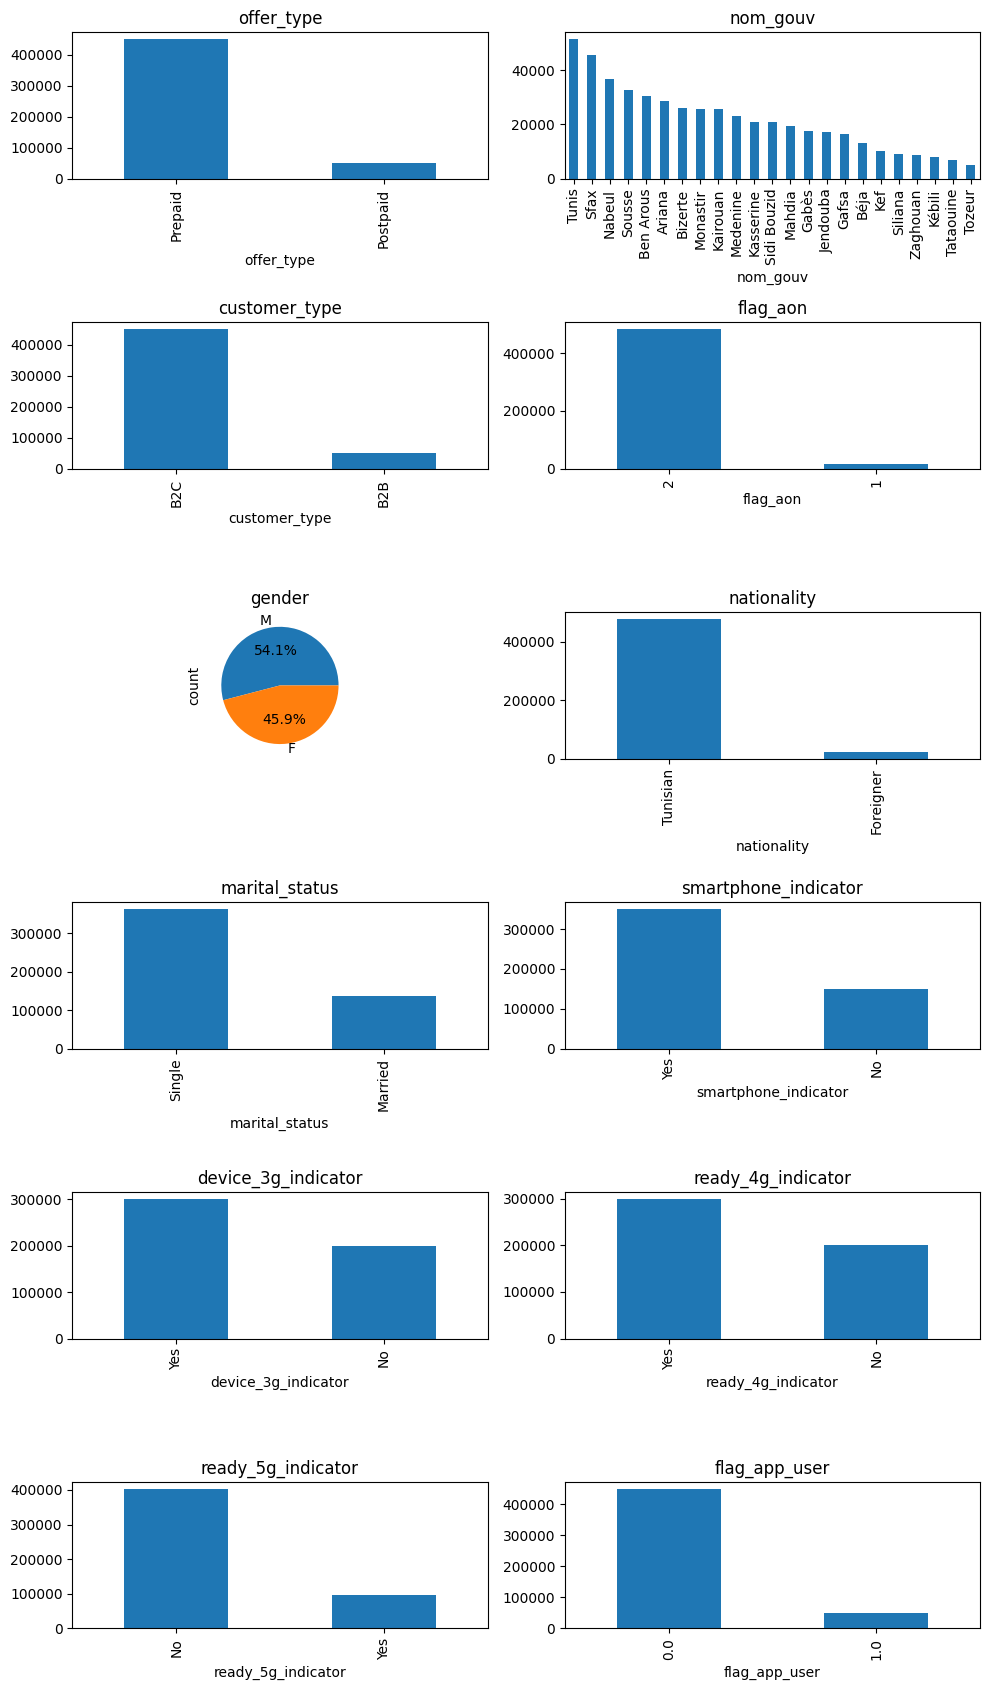

In [ ]:
plt.figure(figsize=(10,17))
plt.subplot(6,2,1)
data['offer_type'].value_counts().plot(kind='bar', title='offer_type')
plt.subplot(6,2,2)
data['nom_gouv'].value_counts().plot(kind='bar', title='nom_gouv')
plt.subplot(6,2,3)
data['customer_type'].value_counts().plot(kind='bar', title='customer_type')
plt.subplot(6,2,4)
data['flag_aon'].value_counts().plot(kind='bar', title='flag_aon')
plt.subplot(6,2,5)
data['gender'].value_counts().plot(kind='pie',autopct='%1.1f%%', title='gender')
plt.subplot(6,2,6)
data['nationality'].value_counts().plot(kind='bar', title='nationality')
plt.subplot(6,2,7)
data['marital_status'].value_counts().plot(kind='bar', title='marital_status')
plt.subplot(6,2,8)
data['smartphone_indicator'].value_counts().plot(kind='bar', title='smartphone_indicator')
plt.subplot(6,2,9)
data['device_3g_indicator'].value_counts().plot(kind='bar', title='device_3g_indicator')
plt.subplot(6,2,10)
data['ready_4g_indicator'].value_counts().plot(kind='bar', title='ready_4g_indicator')
plt.subplot(6,2,11)
data['ready_5g_indicator'].value_counts().plot(kind='bar', title='ready_5g_indicator')
plt.subplot(6,2,12)
data['flag_app_user'].value_counts().plot(kind='bar', title='flag_app_user')
plt.tight_layout()

In [ ]:
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult


<Axes: title={'center': 'minute of use'}, ylabel='Frequency'>

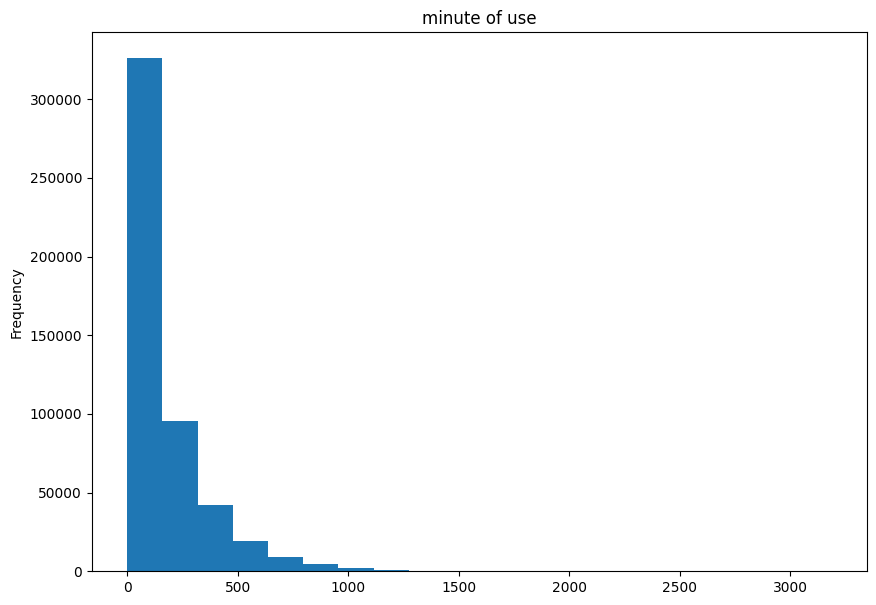

In [ ]:
plt.figure(figsize=(10,7))
data['mou_202505'].plot(kind='hist', bins=20, title='minute of use')


<Axes: title={'center': 'anciennete_mois'}, ylabel='Frequency'>

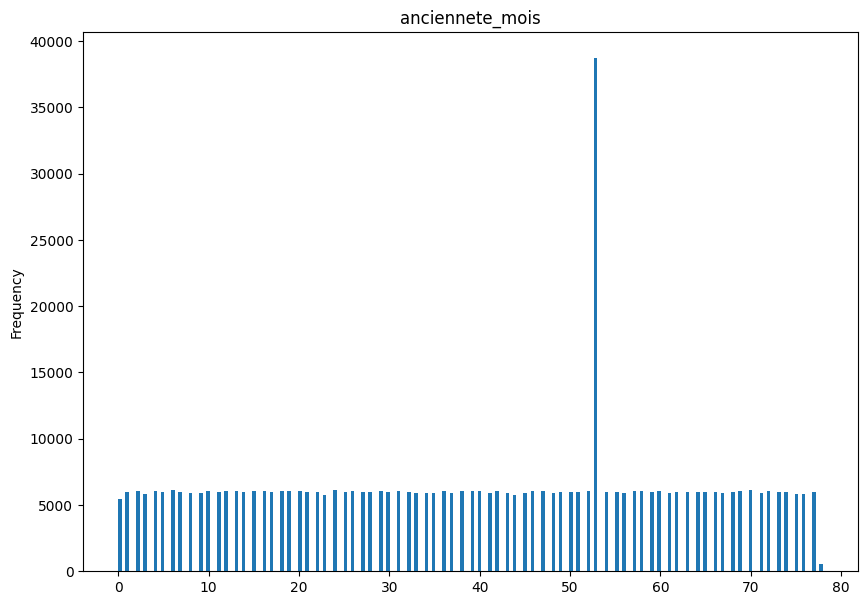

In [ ]:
plt.figure(figsize=(10,7))
data['anciennete_mois'].plot(kind='hist', bins=200, title='anciennete_mois')


<Axes: title={'center': 'age'}, ylabel='Frequency'>

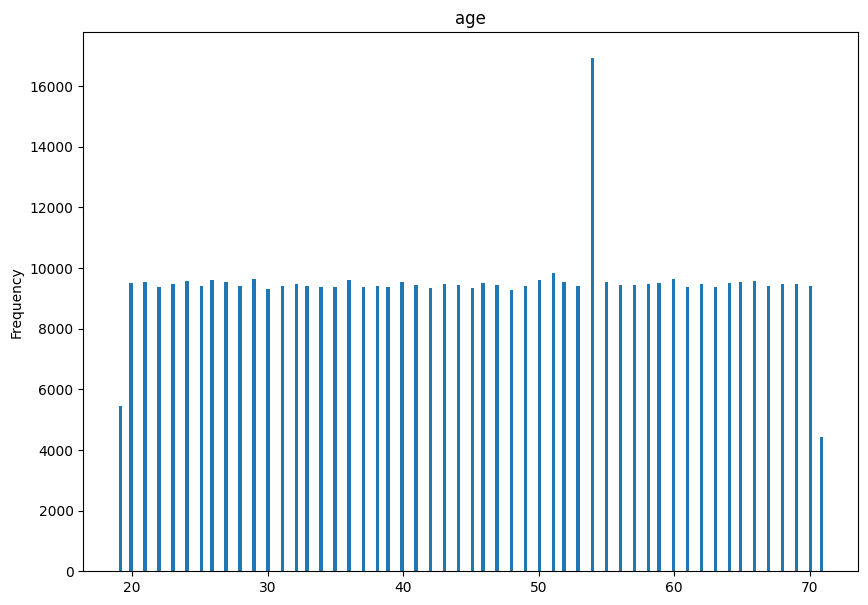

In [ ]:
plt.figure(figsize=(10,7))
data['age'].plot(kind='hist', bins=200, title='age')

In [ ]:
data['anciennete_mois'].value_counts().loc[52]


np.int64(6023)

In [ ]:
data['anciennete_mois'].value_counts().loc[53]

np.int64(38736)

In [ ]:
le_marital_status = LabelEncoder()
data['marital_status_encoded'] = le_marital_status.fit_transform(data['marital_status'])

In [ ]:
import joblib
joblib.dump(le_marital_status, "/content/drive/MyDrive/encoder_marital_status.pkl")

['/content/drive/MyDrive/encoder_marital_status.pkl']

In [ ]:
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0


In [ ]:
from google.colab import files

In [ ]:
le_offer_type = LabelEncoder()
le_customer_type = LabelEncoder()
le_gender = LabelEncoder()
le_nationality = LabelEncoder()
le_smartphone_indicator = LabelEncoder()
le_device_3g_indicator = LabelEncoder()
le_ready_4g_indicator = LabelEncoder()
le_ready_5g_indicator = LabelEncoder()
data['offer_type_encoded'] = le_offer_type.fit_transform(data['offer_type'])
data['customer_type_encoded'] = le_customer_type.fit_transform(data['customer_type'])
data['gender_encoded'] = le_gender.fit_transform(data['gender'])
data['nationality_encoded'] = le_nationality.fit_transform(data['nationality'])
data['smartphone_indicator_encoded'] = le_smartphone_indicator.fit_transform(data['smartphone_indicator'])
data['device_3g_indicator_encoded'] = le_device_3g_indicator.fit_transform(data['device_3g_indicator'])
data['ready_4g_indicator_encoded'] = le_ready_4g_indicator.fit_transform(data['ready_4g_indicator'])
data['ready_5g_indicator_encoded'] = le_ready_5g_indicator.fit_transform(data['ready_5g_indicator'])
data.head()


,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
joblib.dump(le_ready_5g_indicator, '/content/drive/MyDrive/encoder_ready_5g_indicator.pkl')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['/content/drive/MyDrive/encoder_ready_5g_indicator.pkl']

In [ ]:
joblib.dump(le_offer_type, '/content/drive/MyDrive/encoder_offer_type.pkl')

['/content/drive/MyDrive/encoder_offer_type.pkl']

In [ ]:
joblib.dump(le_customer_type, '/content/drive/MyDrive/encoder_customer_type.pkl')

['/content/drive/MyDrive/encoder_customer_type.pkl']

In [ ]:
joblib.dump(le_gender, '/content/drive/MyDrive/encoder_gender.pkl')

['/content/drive/MyDrive/encoder_gender.pkl']

In [ ]:
joblib.dump(le_nationality, '/content/drive/MyDrive/encoder_nationality.pkl')

['/content/drive/MyDrive/encoder_nationality.pkl']

In [ ]:
joblib.dump(le_smartphone_indicator, '/content/drive/MyDrive/encoder_smartphone_indicator.pkl')


['/content/drive/MyDrive/encoder_smartphone_indicator.pkl']

In [ ]:
joblib.dump(le_device_3g_indicator, '/content/drive/MyDrive/encoder_device_3g_indicator.pkl')


['/content/drive/MyDrive/encoder_device_3g_indicator.pkl']

In [ ]:
joblib.dump(le_ready_4g_indicator, '/content/drive/MyDrive/encoder_ready_4g_indicator.pkl')


['/content/drive/MyDrive/encoder_ready_4g_indicator.pkl']

In [ ]:
dummies = pd.get_dummies(data['nom_gouv'], prefix='nom_gouv')
data = pd.concat([data, dummies], axis=1)
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


In [ ]:
dummy_columns_gouv = dummies.columns.tolist()
joblib.dump(dummy_columns_gouv, "/content/drive/MyDrive/dummy_columns_gouv.pkl")

['/content/drive/MyDrive/dummy_columns_gouv.pkl']

In [ ]:
data.dtypes

,0
subscriber_id,int64
subscriber_activation_date,datetime64[ns]
offer_type,object
nom_gouv,object
customer_type,object
flag_aon,int64
gender,object
nationality,object
date_of_birth,datetime64[ns]
marital_status,object


In [ ]:
#data['flag_aon'] = data['anciennete_jours'].apply(lambda x: 1 if x < 90 else 2)

In [ ]:
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


In [ ]:
data[data['anciennete_jours']<90].head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan
17,18,2025-05-13,Postpaid,Kairouan,B2C,1,F,Tunisian,1965-06-12,Single,5.790000,5.23,3.12,1.930000,121.320728,No,Yes,Yes,Yes,0,0.0,18,0,60,lv,dual_play,senior,1,0,1,0,1,0,1,1,1,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
21,22,2025-04-19,Prepaid,Kasserine,B2C,1,F,Tunisian,2005-10-06,Single,8.514565,4.14,3.12,1.139916,341.509638,No,Yes,No,Yes,1,0.0,42,1,19,mv,dual_play,young,1,1,1,0,1,0,1,0,1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
47,48,2025-03-03,Prepaid,Monastir,B2C,1,F,Tunisian,1958-03-13,Married,16.440000,4.74,8.18,0.720000,69.260000,Yes,No,Yes,No,0,0.0,89,2,67,mv,dual_play,senior,0,1,1,0,1,1,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
59,60,2025-05-06,Prepaid,Monastir,B2C,1,M,Tunisian,1959-08-10,Married,10.930000,5.23,6.96,5.110000,37.410000,No,No,Yes,No,0,1.0,25,0,65,mv,mutilplay +,senior,0,1,1,1,1,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
68,69,2025-03-14,Prepaid,Ben Arous,B2C,1,F,Tunisian,2000-07-27,Single,10.250000,5.23,3.12,1.930000,34.090000,No,No,Yes,No,0,0.0,78,2,24,mv,dual_play,young,1,1,1,0,1,0,0,1,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
print("revenue_202505: ",data['revenue_202505'].min())
print("revenue_202505: ",data['revenue_202505'].max())

revenue_202505:  0.0
revenue_202505:  270.7


##### Low: 0 à 144.39
##### medium: 144.39 à 288.78
##### high: 288.78 à 433.17` |


In [ ]:
'''
def get_client_value(row):
    total = row['revenue_202505']
    if total < 1:
        return 'vlv'
    elif total < 7:
        return 'lv'
    elif total < 20:
        return 'mv'
    elif total < 40:
        return 'hv'
    else:
        return 'vhv'

data['client_value'] = data.apply(get_client_value, axis=1)
data.head()


#vlv 0 1
#lv 1 7
#mv 7 20
#hv 20 40
#vhv 40 & +

'''

"\ndef get_client_value(row):\n    total = row['revenue_202505']\n    if total < 1:\n        return 'vlv'\n    elif total < 7:\n        return 'lv'\n    elif total < 20:\n        return 'mv'\n    elif total < 40:\n        return 'hv'\n    else:\n        return 'vhv'\n\ndata['client_value'] = data.apply(get_client_value, axis=1)\ndata.head()\n\n\n#vlv 0 1\n#lv 1 7\n#mv 7 20\n#hv 20 40\n#vhv 40 & +\n\n"

In [ ]:
data[data['client_value']=='vhv'].head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.74,5.23,40.55,0.85,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
6,7,2020-04-11,Prepaid,Mahdia,B2C,2,M,Tunisian,1997-05-04,Married,48.32,18.94,3.12,0.34,237.360000,No,No,No,Yes,0,0.0,1876,62,28,vhv,dual_play,adult,0,1,1,1,1,0,0,0,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
9,10,2023-01-22,Prepaid,Kairouan,B2C,2,M,Tunisian,1997-08-09,Single,84.91,33.50,21.70,1.93,259.740000,No,No,Yes,Yes,0,0.0,860,28,27,vhv,dual_play,adult,1,1,1,1,1,0,0,1,1,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12,13,2023-08-13,Prepaid,Tunis,B2C,2,M,Tunisian,1991-06-19,Single,110.64,5.23,3.12,1.93,121.320728,Yes,No,Yes,No,0,0.0,657,21,33,vhv,dual_play,adult,1,1,1,1,1,1,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
16,17,2021-08-13,Postpaid,Nabeul,B2C,2,M,Tunisian,1982-10-25,Married,68.36,34.14,22.72,0.86,220.240000,Yes,Yes,Yes,No,0,0.0,1387,46,42,vhv,dual_play,adult,0,0,1,1,1,1,1,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


In [ ]:
dummies = pd.get_dummies(data['client_value'], prefix='client_value')
data = pd.concat([data, dummies], axis=1 )
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


In [ ]:
#dummy_columns_client_value = dummies.columns.tolist()
#joblib.dump(dummy_columns_client_value, "/content/drive/MyDrive/dummy_columns_client_value.pkl")

In [ ]:
data['nom_gouv_Ariana'] =  data['nom_gouv_Ariana'].astype(int)
data['nom_gouv_Ben Arous'] =  data['nom_gouv_Ben Arous'].astype(int)
data['nom_gouv_Bizerte'] =  data['nom_gouv_Bizerte'].astype(int)
data['nom_gouv_Béja'] =  data['nom_gouv_Béja'].astype(int)
data['nom_gouv_Gabès'] =  data['nom_gouv_Gabès'].astype(int)
data['nom_gouv_Gafsa'] =  data['nom_gouv_Gafsa'].astype(int)
data['nom_gouv_Jendouba'] =  data['nom_gouv_Jendouba'].astype(int)
data['nom_gouv_Kairouan'] =  data['nom_gouv_Kairouan'].astype(int)
data['nom_gouv_Kasserine'] =  data['nom_gouv_Kasserine'].astype(int)
data['nom_gouv_Kef'] =  data['nom_gouv_Kef'].astype(int)
data['nom_gouv_Kébili'] =  data['nom_gouv_Kébili'].astype(int)
data['nom_gouv_Mahdia'] =  data['nom_gouv_Mahdia'].astype(int)
data['nom_gouv_Medenine'] =  data['nom_gouv_Medenine'].astype(int)
data['nom_gouv_Monastir'] =  data['nom_gouv_Monastir'].astype(int)
data['nom_gouv_Nabeul'] =  data['nom_gouv_Nabeul'].astype(int)
data['nom_gouv_Sfax'] =  data['nom_gouv_Sfax'].astype(int)
data['nom_gouv_Sidi Bouzid'] =  data['nom_gouv_Sidi Bouzid'].astype(int)
data['nom_gouv_Siliana'] =  data['nom_gouv_Siliana'].astype(int)
data['nom_gouv_Siliana'] =  data['nom_gouv_Siliana'].astype(int)
data['nom_gouv_Sousse'] =  data['nom_gouv_Sousse'].astype(int)
data['nom_gouv_Tataouine'] =  data['nom_gouv_Tataouine'].astype(int)
data['nom_gouv_Tozeur'] =  data['nom_gouv_Tozeur'].astype(int)
data['nom_gouv_Tunis'] =  data['nom_gouv_Tunis'].astype(int)
data['nom_gouv_Zaghouan'] =  data['nom_gouv_Zaghouan'].astype(int)
data['client_value_hv'] =  data['client_value_hv'].astype(int)
data['client_value_lv'] =  data['client_value_lv'].astype(int)
data['client_value_mv'] =  data['client_value_mv'].astype(int)
data['client_value_vhv'] =  data['client_value_vhv'].astype(int)
data['client_value_vlv'] =  data['client_value_vlv'].astype(int)
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
'''def get_client_type(row):
    data = row['vol_data_202505'] > 0.1
    appels = row['mou_202505'] > 10
    vas = row['revenue_vas_202505'] > 0
    app = row['flag_app_user'] == 1

    if data and not appels:
        return 'single_data'
    elif appels and not data:
        return 'single_voice'

    elif data and appels and vas and app:
        return 'mutilplay +'

    elif data and appels:
        return 'dual_play'

    elif data and appels and  app:
        return 'mutilplay'
    else:
        return 'no play'


'''

"def get_client_type(row):\n    data = row['vol_data_202505'] > 0.1\n    appels = row['mou_202505'] > 10\n    vas = row['revenue_vas_202505'] > 0\n    app = row['flag_app_user'] == 1\n\n    if data and not appels:\n        return 'single_data'\n    elif appels and not data:\n        return 'single_voice'\n\n    elif data and appels and vas and app:\n        return 'mutilplay +'\n\n    elif data and appels:\n        return 'dual_play'\n\n    elif data and appels and  app:\n        return 'mutilplay'\n    else:\n        return 'no play'\n\n\n"

###### no play
###### single_data 100 mb
###### single_voice 10 min
###### dual_play data +voice
###### mutilplay data +voice+app
###### mutilplay +  data +voice+app +vas
###### segment revenue


In [ ]:
#data['client_type'] = data.apply(get_client_type, axis=1)
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
data['client_type'].value_counts()

,count
client_type,
dual_play,415181
mutilplay +,46065
single_data,24337
single_voice,13443
no play,870
mutilplay,104


In [ ]:
dummies = pd.get_dummies(data['client_type'], prefix= 'client_type')
data = pd.concat([data, dummies], axis=1)
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv,client_type_dual_play,client_type_mutilplay,client_type_mutilplay +,client_type_no play,client_type_single_data,client_type_single_voice
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,True,False,False,False,False,False
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,True,False,False,False,False,False
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,True,False,False,False,False,False
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,False,False,True,False,False,False
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,True,False,False,False,False,False


In [ ]:
dummy_columns_client_type = dummies.columns.tolist()
joblib.dump(dummy_columns_client_type, "/content/drive/MyDrive/dummy_columns_client_type.pkl")

['/content/drive/MyDrive/dummy_columns_client_type.pkl']

In [ ]:
data['client_type_dual_play']=data['client_type_dual_play'].astype(int)
data['client_type_mutilplay +']=data['client_type_mutilplay +'].astype(int)
data['client_type_mutilplay']=data['client_type_mutilplay'].astype(int)
data['client_type_no play']=data['client_type_no play'].astype(int)
data['client_type_single_data']=data['client_type_single_data'].astype(int)
data['client_type_single_voice']=data['client_type_single_voice'].astype(int)
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv,client_type_dual_play,client_type_mutilplay,client_type_mutilplay +,client_type_no play,client_type_single_data,client_type_single_voice
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0


In [ ]:
'''def age_group (age):
    if (age<25):
        return "young"
    elif (age < 45):
        return "adult"
    else:
        return "senior"

data['age_group']=data['age'].apply(age_group)
data.head()'''

'def age_group (age):\n    if (age<25):\n        return "young"\n    elif (age < 45):\n        return "adult"\n    else:\n        return "senior"\n\ndata[\'age_group\']=data[\'age\'].apply(age_group)\ndata.head()'

In [ ]:
dummies= pd.get_dummies(data['age_group'], prefix = 'age_group')
data = pd.concat([data, dummies], axis = 1)
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv,client_type_dual_play,client_type_mutilplay,client_type_mutilplay +,client_type_no play,client_type_single_data,client_type_single_voice,age_group_adult,age_group_senior,age_group_young
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,True,False,False
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,True,False,False
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,False,True,False
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,False,True,False
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,True,False,False


In [ ]:
#dummy_columns_age_group = dummies.columns.tolist()
#joblib.dump(dummy_columns_age_group, "/content/drive/MyDrive/dummy_columns_age_group.pkl")

In [ ]:
data['age_group_adult']=data['age_group_adult'].astype(int)
data['age_group_senior']=data['age_group_senior'].astype(int)
data['age_group_young']=data['age_group_young'].astype(int)
data.head()

,subscriber_id,subscriber_activation_date,offer_type,nom_gouv,customer_type,flag_aon,gender,nationality,date_of_birth,marital_status,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,smartphone_indicator,device_3g_indicator,ready_4g_indicator,ready_5g_indicator,flag_churn,flag_app_user,anciennete_jours,anciennete_mois,age,client_value,client_type,age_group,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv,client_type_dual_play,client_type_mutilplay,client_type_mutilplay +,client_type_no play,client_type_single_data,client_type_single_voice,age_group_adult,age_group_senior,age_group_young
0,1,2021-05-10,Prepaid,Kairouan,B2C,2,F,Tunisian,1983-11-26,Single,10.037098,7.74,0.99,1.930000,39.094801,Yes,Yes,No,No,1,0.0,1482,49,41,mv,dual_play,adult,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0
1,2,2022-07-18,Prepaid,Kef,B2C,2,M,Tunisian,1987-02-13,Single,21.730000,4.92,3.12,2.320000,305.460000,No,Yes,Yes,No,0,0.0,1048,34,38,hv,dual_play,adult,1,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
2,3,2021-01-02,Prepaid,Gafsa,B2C,2,F,Tunisian,1973-12-07,Single,14.460176,13.26,3.12,0.700346,16.889108,Yes,No,Yes,No,1,0.0,1610,53,51,mv,dual_play,senior,1,1,1,0,1,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0
3,4,2021-12-31,Prepaid,Sidi Bouzid,B2C,2,F,Tunisian,1967-01-28,Single,68.740000,5.23,40.55,0.850000,47.190000,No,No,Yes,No,0,1.0,1247,41,58,vhv,mutilplay +,senior,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0
4,5,2023-06-27,Prepaid,Sfax,B2C,2,F,Tunisian,1983-05-27,Married,0.800000,5.23,0.32,1.930000,97.880000,Yes,Yes,Yes,Yes,0,0.0,704,23,42,vlv,dual_play,adult,0,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0


In [ ]:
data.shape

(500000, 73)

In [ ]:
def plot_churn_bar(col):
    plt.figure(figsize=(7,4))
    sns.barplot(data=data, x=col, y='flag_churn', estimator='mean')
    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=75)
    plt.show()


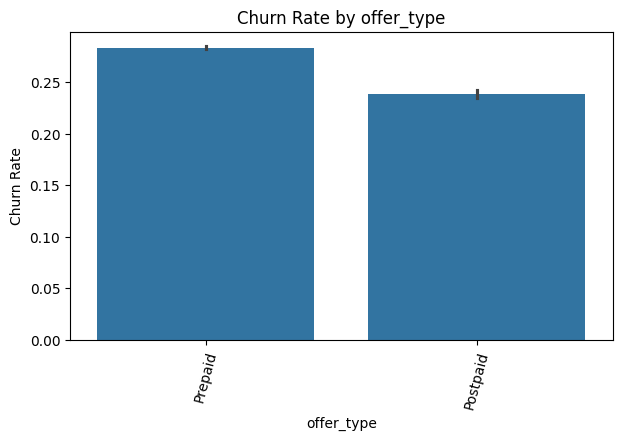

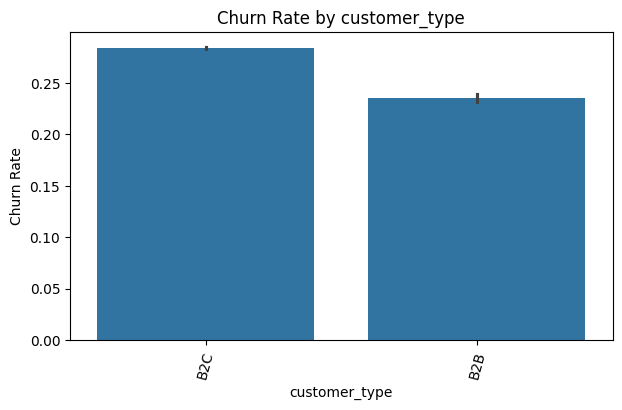

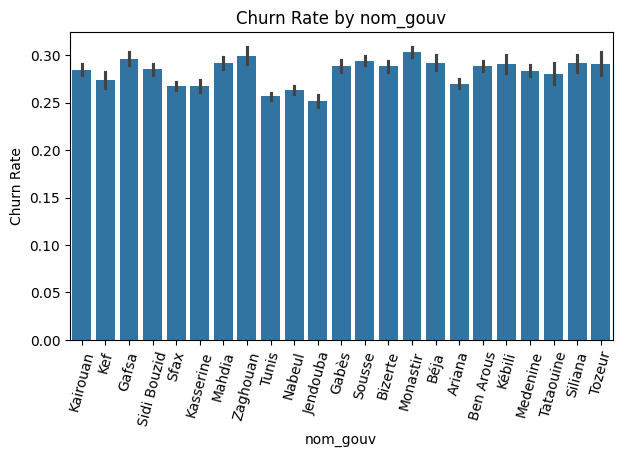

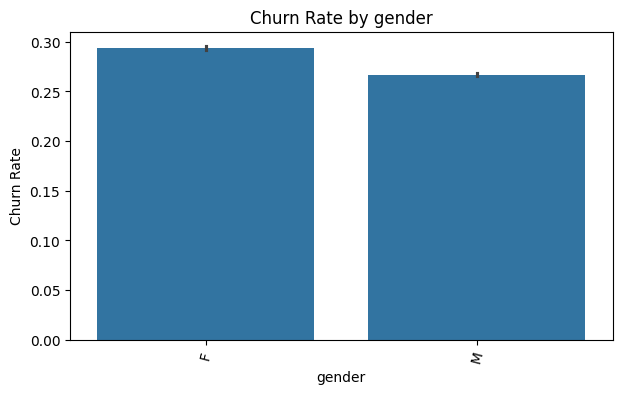

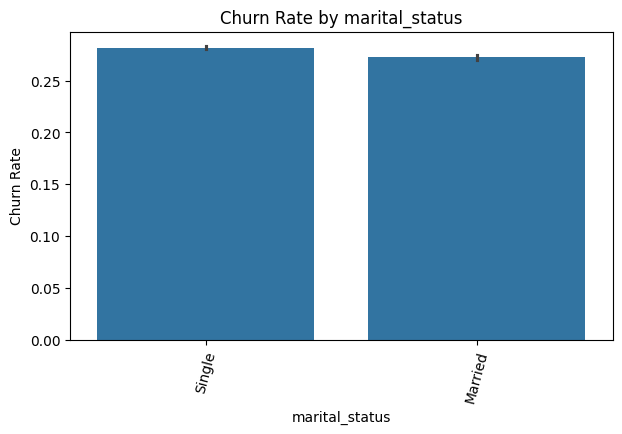

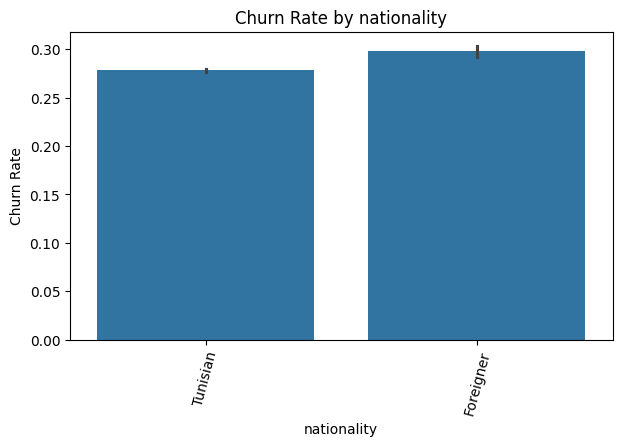

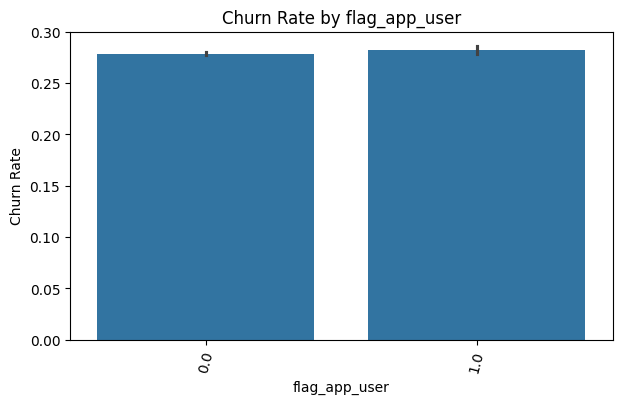

KeyboardInterrupt: 

<Figure size 700x400 with 0 Axes>

In [ ]:
plot_churn_bar('offer_type')
plot_churn_bar('customer_type')
plot_churn_bar('nom_gouv')
plot_churn_bar('gender')
plot_churn_bar('marital_status')
plot_churn_bar('nationality')
plot_churn_bar('flag_app_user')
plot_churn_bar('smartphone_indicator')
plot_churn_bar('ready_4g_indicator')
plot_churn_bar('ready_5g_indicator')

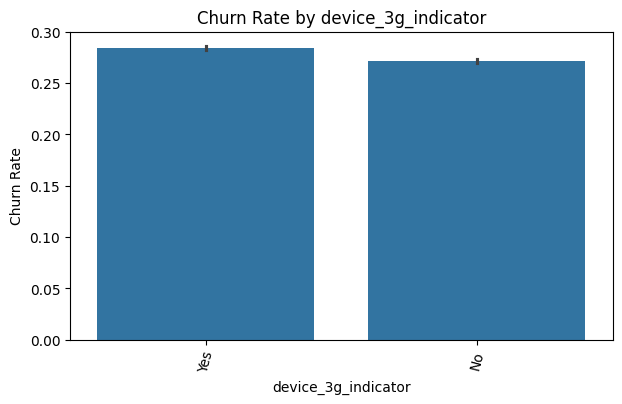

In [ ]:
plot_churn_bar('device_3g_indicator')

In [ ]:
data.groupby('marital_status')['flag_churn'].mean()

,flag_churn
marital_status,
Married,0.272727
Single,0.281527


In [ ]:
scaler= StandardScaler()


In [ ]:
X = data.drop(columns=['flag_churn'])
y = data['flag_churn']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
X_train= X_train.drop(columns=['subscriber_activation_date'])
X_train= X_train.drop(columns=['date_of_birth'])



In [ ]:
X_test= X_test.drop(columns=['subscriber_activation_date'])
X_test= X_test.drop(columns=['date_of_birth'])

In [ ]:
print(X_train.columns)

Index(['subscriber_id', 'offer_type', 'nom_gouv', 'customer_type', 'flag_aon',
       'gender', 'nationality', 'marital_status', 'revenue_202505',
       'revenue_data_202505', 'revenue_vas_202505', 'vol_data_202505',
       'mou_202505', 'smartphone_indicator', 'device_3g_indicator',
       'ready_4g_indicator', 'ready_5g_indicator', 'flag_app_user',
       'anciennete_jours', 'anciennete_mois', 'age', 'client_value',
       'client_type', 'age_group', 'marital_status_encoded',
       'offer_type_encoded', 'customer_type_encoded', 'gender_encoded',
       'nationality_encoded', 'smartphone_indicator_encoded',
       'device_3g_indicator_encoded', 'ready_4g_indicator_encoded',
       'ready_5g_indicator_encoded', 'nom_gouv_Ariana', 'nom_gouv_Ben Arous',
       'nom_gouv_Bizerte', 'nom_gouv_Béja', 'nom_gouv_Gabès', 'nom_gouv_Gafsa',
       'nom_gouv_Jendouba', 'nom_gouv_Kairouan', 'nom_gouv_Kasserine',
       'nom_gouv_Kef', 'nom_gouv_Kébili', 'nom_gouv_Mahdia',
       'nom_gouv_Medenin

In [ ]:
X_train= X_train.drop(columns=['offer_type'])
X_train= X_train.drop(columns=['nom_gouv'])
X_train= X_train.drop(columns=['customer_type'])
X_train= X_train.drop(columns=['gender'])
X_train= X_train.drop(columns=['nationality'])
X_train= X_train.drop(columns=['marital_status'])
X_train= X_train.drop(columns=['smartphone_indicator'])
X_train= X_train.drop(columns=['device_3g_indicator'])
X_train= X_train.drop(columns=['ready_4g_indicator'])
X_train= X_train.drop(columns=['ready_5g_indicator'])
X_train= X_train.drop(columns=['client_type'])
X_train= X_train.drop(columns=['age_group'])
X_train = X_train.drop(columns = ['subscriber_id'])
X_train = X_train.drop(columns = ['client_value'])

In [ ]:
X_test= X_test.drop(columns=['offer_type'])
X_test= X_test.drop(columns=['nom_gouv'])
X_test= X_test.drop(columns=['customer_type'])
X_test= X_test.drop(columns=['gender'])
X_test= X_test.drop(columns=['nationality'])
X_test= X_test.drop(columns=['marital_status'])
X_test= X_test.drop(columns=['smartphone_indicator'])
X_test= X_test.drop(columns=['device_3g_indicator'])
X_test= X_test.drop(columns=['ready_4g_indicator'])
X_test= X_test.drop(columns=['ready_5g_indicator'])
X_test= X_test.drop(columns=['client_type'])
X_test= X_test.drop(columns=['age_group'])
X_test = X_test.drop(columns = ['subscriber_id'])
X_test = X_test.drop(columns = ['client_value'])

In [ ]:
final_features = X_train.columns.tolist()
print(final_features)


['flag_aon', 'revenue_202505', 'revenue_data_202505', 'revenue_vas_202505', 'vol_data_202505', 'mou_202505', 'flag_app_user', 'anciennete_jours', 'anciennete_mois', 'age', 'marital_status_encoded', 'offer_type_encoded', 'customer_type_encoded', 'gender_encoded', 'nationality_encoded', 'smartphone_indicator_encoded', 'device_3g_indicator_encoded', 'ready_4g_indicator_encoded', 'ready_5g_indicator_encoded', 'nom_gouv_Ariana', 'nom_gouv_Ben Arous', 'nom_gouv_Bizerte', 'nom_gouv_Béja', 'nom_gouv_Gabès', 'nom_gouv_Gafsa', 'nom_gouv_Jendouba', 'nom_gouv_Kairouan', 'nom_gouv_Kasserine', 'nom_gouv_Kef', 'nom_gouv_Kébili', 'nom_gouv_Mahdia', 'nom_gouv_Medenine', 'nom_gouv_Monastir', 'nom_gouv_Nabeul', 'nom_gouv_Sfax', 'nom_gouv_Sidi Bouzid', 'nom_gouv_Siliana', 'nom_gouv_Sousse', 'nom_gouv_Tataouine', 'nom_gouv_Tozeur', 'nom_gouv_Tunis', 'nom_gouv_Zaghouan', 'client_value_hv', 'client_value_lv', 'client_value_mv', 'client_value_vhv', 'client_value_vlv', 'client_type_dual_play', 'client_type_mut

In [ ]:
joblib.dump(final_features, "/content/drive/MyDrive/final_features.pkl")

['/content/drive/MyDrive/final_features.pkl']

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [ ]:
model =  LogisticRegression(random_state=42, max_iter=1000)

In [ ]:
X_train_scaled.head()

,flag_aon,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,flag_app_user,anciennete_jours,anciennete_mois,age,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv,client_type_dual_play,client_type_mutilplay,client_type_mutilplay +,client_type_no play,client_type_single_data,client_type_single_voice,age_group_adult,age_group_senior,age_group_young
178847,0.190071,-0.862726,-0.274469,-0.667526,-0.804977,-0.535786,-0.332648,-1.085758,-1.065130,-1.074986,0.614341,0.332685,-3.003296,0.921816,0.222887,0.652784,-1.227153,-1.220875,-0.490336,-0.245788,-0.255095,-0.234888,-0.16426,5.211820,-0.185296,-0.189739,-0.232036,-0.209403,-0.142702,-0.127799,-0.199637,-0.220934,-0.234129,-0.281905,-0.316822,-0.208412,-0.136618,-0.263908,-0.117966,-0.102066,-0.338724,-0.13189,-0.472433,1.623851,-0.791663,-0.326326,-0.255017,0.451142,-0.014232,-0.31771,-0.041569,-0.226155,-0.166073,1.284499,-1.033853,-0.344324
31002,0.190071,-0.791584,-0.843890,-0.706171,0.683069,0.494614,-0.332648,0.457279,0.476864,1.597036,-1.627760,0.332685,0.332967,0.921816,0.222887,0.652784,0.814894,-1.220875,-0.490336,-0.245788,-0.255095,-0.234888,-0.16426,-0.191872,-0.185296,-0.189739,-0.232036,-0.209403,-0.142702,-0.127799,-0.199637,-0.220934,-0.234129,-0.281905,3.156344,-0.208412,-0.136618,-0.263908,-0.117966,-0.102066,-0.338724,-0.13189,-0.472433,1.623851,-0.791663,-0.326326,-0.255017,0.451142,-0.014232,-0.31771,-0.041569,-0.226155,-0.166073,-0.778514,0.967256,-0.344324
211205,0.190071,-0.767455,-0.526227,-0.414725,1.426339,-0.821114,-0.332648,-0.735137,-0.747661,-1.141786,0.614341,0.332685,0.332967,-1.084815,0.222887,0.652784,-1.227153,0.819085,2.039418,-0.245788,-0.255095,4.257350,-0.16426,-0.191872,-0.185296,-0.189739,-0.232036,-0.209403,-0.142702,-0.127799,-0.199637,-0.220934,-0.234129,-0.281905,-0.316822,-0.208412,-0.136618,-0.263908,-0.117966,-0.102066,-0.338724,-0.13189,-0.472433,1.623851,-0.791663,-0.326326,-0.255017,0.451142,-0.014232,-0.31771,-0.041569,-0.226155,-0.166073,1.284499,-1.033853,-0.344324
445775,0.190071,-0.648917,-0.721306,-0.266586,0.580760,-0.633517,-0.332648,-1.206662,-1.201189,0.929031,-1.627760,0.332685,0.332967,-1.084815,0.222887,0.652784,-1.227153,0.819085,-0.490336,-0.245788,-0.255095,-0.234888,-0.16426,-0.191872,-0.185296,-0.189739,-0.232036,-0.209403,-0.142702,-0.127799,-0.199637,-0.220934,-0.234129,3.547290,-0.316822,-0.208412,-0.136618,-0.263908,-0.117966,-0.102066,-0.338724,-0.13189,-0.472433,1.623851,-0.791663,-0.326326,-0.255017,0.451142,-0.014232,-0.31771,-0.041569,-0.226155,-0.166073,-0.778514,0.967256,-0.344324
195855,0.190071,-0.676331,-0.704171,-0.266586,-0.262403,0.113954,-0.332648,-0.525066,-0.520897,-1.609390,0.614341,0.332685,0.332967,0.921816,0.222887,0.652784,-1.227153,0.819085,-0.490336,-0.245788,-0.255095,-0.234888,-0.16426,-0.191872,-0.185296,-0.189739,-0.232036,-0.209403,-0.142702,-0.127799,-0.199637,-0.220934,-0.234129,-0.281905,-0.316822,-0.208412,-0.136618,-0.263908,-0.117966,-0.102066,-0.338724,7.58209,-0.472433,1.623851,-0.791663,-0.326326,-0.255017,0.451142,-0.014232,-0.31771,-0.041569,-0.226155,-0.166073,-0.778514,-1.033853,2.904243


In [ ]:
model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      1.00      0.84     72089
           1       0.53      0.00      0.00     27911

    accuracy                           0.72    100000
   macro avg       0.63      0.50      0.42    100000
weighted avg       0.67      0.72      0.60    100000



In [ ]:
y_proba = model.predict_proba(X_test)[:,1]

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_proba))

ROC AUC: 0.7405965646888445


In [ ]:
model_rf = RandomForestClassifier(class_weight='balanced')

In [ ]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

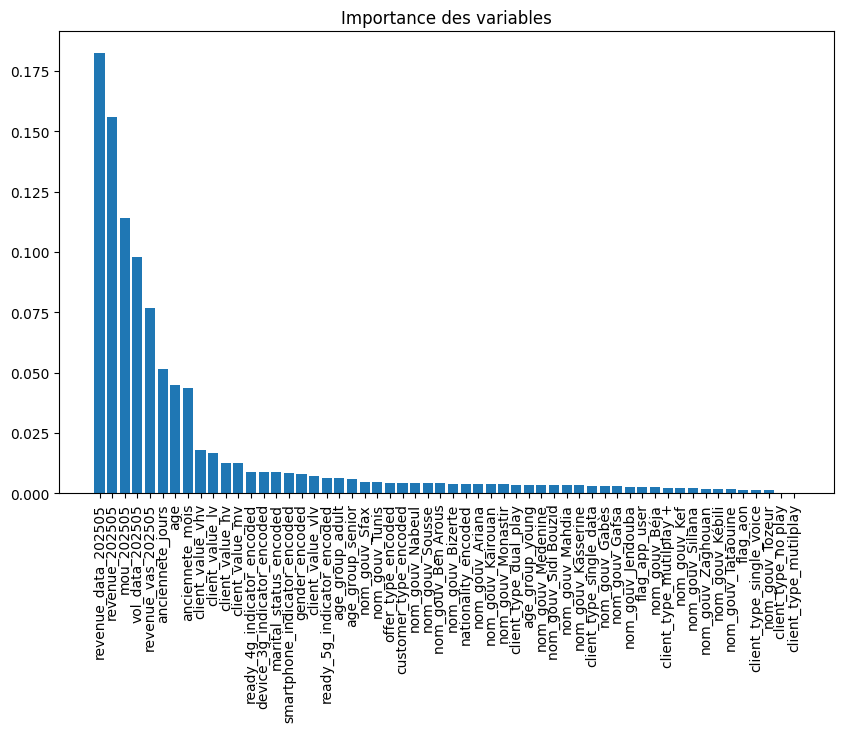

In [ ]:
import numpy as np
# Récupération des importances
importances = model_rf.feature_importances_
feature_names = X_train.columns
# Ordre des importances
indices = np.argsort(importances)[::-1]

# Affichage graphique
plt.figure(figsize=(10,6))
plt.title("Importance des variables")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.show()


In [ ]:
y_pred_rf = model_rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     72089
           1       0.87      0.67      0.76     27911

    accuracy                           0.88    100000
   macro avg       0.88      0.82      0.84    100000
weighted avg       0.88      0.88      0.88    100000



In [ ]:
y_prob= model_rf.predict_proba(X_test)[:,1]

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.917585151858465


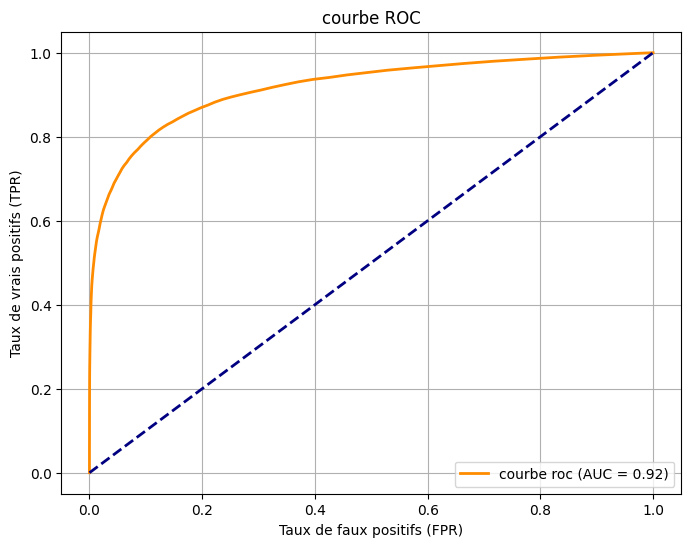

In [ ]:
#calculer les points de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#calculer l'auc (aire sous la courbe)
roc_auc = auc(fpr, tpr)

#tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'courbe roc (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # diagonale
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('courbe ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(class_weight='balanced')

In [ ]:
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced')

In [ ]:
y_pred_dt = model_dt.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89     72089
           1       0.72      0.74      0.73     27911

    accuracy                           0.85    100000
   macro avg       0.81      0.81      0.81    100000
weighted avg       0.85      0.85      0.85    100000



In [ ]:
y_prob_dt= model_dt.predict_proba(X_test)[:,1]

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_dt))


ROC AUC: 0.813092756320175


In [ ]:
import xgboost as xgb

#creer le modèle
model_xgb = xgb.XGBClassifier()

In [ ]:
X_train.head()

,flag_aon,revenue_202505,revenue_data_202505,revenue_vas_202505,vol_data_202505,mou_202505,flag_app_user,anciennete_jours,anciennete_mois,age,marital_status_encoded,offer_type_encoded,customer_type_encoded,gender_encoded,nationality_encoded,smartphone_indicator_encoded,device_3g_indicator_encoded,ready_4g_indicator_encoded,ready_5g_indicator_encoded,nom_gouv_Ariana,nom_gouv_Ben Arous,nom_gouv_Bizerte,nom_gouv_Béja,nom_gouv_Gabès,nom_gouv_Gafsa,nom_gouv_Jendouba,nom_gouv_Kairouan,nom_gouv_Kasserine,nom_gouv_Kef,nom_gouv_Kébili,nom_gouv_Mahdia,nom_gouv_Medenine,nom_gouv_Monastir,nom_gouv_Nabeul,nom_gouv_Sfax,nom_gouv_Sidi Bouzid,nom_gouv_Siliana,nom_gouv_Sousse,nom_gouv_Tataouine,nom_gouv_Tozeur,nom_gouv_Tunis,nom_gouv_Zaghouan,client_value_hv,client_value_lv,client_value_mv,client_value_vhv,client_value_vlv,client_type_dual_play,client_type_mutilplay,client_type_mutilplay +,client_type_no play,client_type_single_data,client_type_single_voice,age_group_adult,age_group_senior,age_group_young
178847,2,1.258416,5.23,0.63,0.442040,76.925926,0.0,481,16,29,1,1,0,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0
31002,2,2.530000,0.91,0.39,4.660000,271.090000,0.0,1502,50,69,0,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0
211205,2,2.961283,3.32,2.20,6.766847,23.160055,0.0,713,23,28,1,1,1,0,1,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0
445775,2,5.080000,1.84,3.12,4.370000,58.510000,0.0,401,13,59,0,1,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0
195855,2,4.590000,1.97,3.12,1.980000,199.360000,0.0,852,28,21,1,1,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1


In [ ]:
#entraîner
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Predire
y_pred_xgb = model_xgb.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93     72089
           1       0.91      0.71      0.80     27911

    accuracy                           0.90    100000
   macro avg       0.90      0.84      0.87    100000
weighted avg       0.90      0.90      0.90    100000



In [ ]:
y_prob_xgb = model_xgb.predict_proba(X_test)[:,1]

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

ROC AUC: 0.9367862677621943


In [ ]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()

In [ ]:
model_NB.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_NB = model_NB.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_NB))

              precision    recall  f1-score   support

           0       0.86      0.66      0.75     72089
           1       0.46      0.73      0.56     27911

    accuracy                           0.68    100000
   macro avg       0.66      0.70      0.66    100000
weighted avg       0.75      0.68      0.70    100000



In [ ]:
y_prob_NB = model_NB.predict_proba(X_test)[:,1]

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, y_prob_NB))

ROC AUC: 0.7528150977038677


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn= model_knn.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84     72089
           1       0.57      0.43      0.49     27911

    accuracy                           0.75    100000
   macro avg       0.69      0.65      0.66    100000
weighted avg       0.74      0.75      0.74    100000



In [ ]:
y_prob_knn= model_knn.predict_proba(X_test)[:,1]

In [ ]:
print("ROC AUC: ", roc_auc_score(y_test, y_prob_knn))

ROC AUC:  0.7485524037682275


In [ ]:
from sklearn.neural_network import MLPClassifier
model_mlp = MLPClassifier(hidden_layer_sizes=(100,))

In [ ]:
model_mlp.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier()

In [ ]:
y_pred_mlp = model_mlp.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91     72089
           1       0.84      0.67      0.75     27911

    accuracy                           0.87    100000
   macro avg       0.86      0.81      0.83    100000
weighted avg       0.87      0.87      0.87    100000



In [ ]:
y_prob_mlp = model_mlp.predict_proba(X_test)[:,1]

In [ ]:
print("ROC AUC: ", roc_auc_score(y_test, y_prob_mlp))

ROC AUC:  0.9103280090235595


#### => XGBoost est le plus performant

In [ ]:
from xgboost import XGBClassifier
xgb_base = XGBClassifier()

for n_est in[100, 200, 300, 500]:
  xgb = XGBClassifier(n_estimators=n_est)
  xgb.fit(X_train, y_train)
  score = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
  print(f"n_estimators={n_est}: AUC={score}")

n_estimators=100: AUC=0.9367862677621943
n_estimators=200: AUC=0.9362071882670596
n_estimators=300: AUC=0.9357345965445475
n_estimators=500: AUC=0.9342141699404398


In [ ]:
for depth in [3, 6, 9, 12]:
  xgb = XGBClassifier(n_estimators=100, max_depth=depth)
  xgb.fit(X_train, y_train)
  score = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
  print(f"max_depth={depth}: AUC={score}")

max_depth=3: AUC=0.9288596964627996
max_depth=6: AUC=0.9367862677621943
max_depth=9: AUC=0.935350394620938
max_depth=12: AUC=0.9316477244894475


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [100,200,300], 'max_depth': [3,6,9], 'learning_rate': [0.01, 0.1, 0.2]}
grid_search = GridSearchCV(XGBClassifier(), param_grid, cv=3, scoring='roc_auc')
grid_search.fit(X_train, y_train)

print("meilleurs parametres:", grid_search.best_params_)
print("meilleur score:", grid_search.best_score_)

meilleurs parametres: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
meilleur score: 0.936804271009032


In [ ]:
from sklearn.model_selection import cross_val_score

#mon XGBoost optimisé
xgb_optimized = XGBClassifier( learning_rate=0.1, max_depth=6, n_estimators=300)

#test sur 5 "morceaux" differents
cv_scores = cross_val_score(xgb_optimized, X_train, y_train, cv=5, scoring='roc_auc')

print("scores AUC sur 5 tests:", cv_scores)
print("Moyenne des scores:", cv_scores.mean())
print("Ecart-type:", cv_scores.std())

scores AUC sur 5 tests: [0.93561714 0.93771555 0.93611528 0.93750137 0.93901789]
Moyenne des scores: 0.9371934440472426
Ecart-type: 0.0012118742739802635


In [ ]:
from sklearn.ensemble import VotingClassifier

#les 3 meilleurs modèles
xgb_model = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=300)
rf_model = RandomForestClassifier()
nn_model = MLPClassifier(hidden_layer_sizes=(100,))

#l'ensemble qui combine les 3
ensemble = VotingClassifier(estimators=[('xgb', xgb_model),('rf', rf_model), ('nn', nn_model)], voting='soft')

In [ ]:
ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('rf', RandomForestClassifier()),
                             ('nn', MLPClassifier())],
                 voting='soft')

In [ ]:
ensemble_pred = ensemble.predict(X_test)
ensemble_proba = ensemble.predict_proba(X_test)[:,1]

In [ ]:
print("ROC AUC:", roc_auc_score(y_test, ensemble_proba))
print(classification_report(y_test, ensemble_pred))

ROC AUC: 0.9303274436473234
              precision    recall  f1-score   support

           0       0.90      0.96      0.93     72089
           1       0.87      0.72      0.79     27911

    accuracy                           0.89    100000
   macro avg       0.89      0.84      0.86    100000
weighted avg       0.89      0.89      0.89    100000



In [ ]:
#les 3 meilleurs modèles
xgb_model_opt = XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=300)
xgb_model_opt.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb_opt = xgb_model_opt.predict(X_test)
print(classification_report(y_test, y_pred_xgb_opt))
y_proba_xgb_opt = xgb_model_opt.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb_opt))


              precision    recall  f1-score   support

           0       0.90      0.97      0.93     72089
           1       0.92      0.71      0.80     27911

    accuracy                           0.90    100000
   macro avg       0.91      0.84      0.87    100000
weighted avg       0.90      0.90      0.90    100000

ROC AUC: 0.9376914035167554


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
xgb_model_opt.save_model("/content/drive/MyDrive/xgb_saved_model.json")

NameError: name 'xgb_model_opt' is not defined

In [ ]:
import joblib
joblib.dump(model_mlp, '/content/drive/MyDrive/mlp_model.pkl')

NameError: name 'model_mlp' is not defined

In [ ]:
joblib.dump(model_rf, '/content/drive/MyDrive/rf_model.pkl')

['/content/drive/MyDrive/rf_model.pkl']

In [ ]:
! pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 54.0 MB/s eta 0:00:00


In [ ]:

!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 8s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# new code

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from features import preprocess

# Configure page
st.set_page_config(
    page_title="Ooredoo Churn Detection",
    page_icon="📊",
    layout="wide"
)

def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum() > 0

def impute_column(col):
    if detect_outliers_iqr(col):
        return col.fillna(col.median())
    else:
        return col.fillna(col.mean())

def clean_categorical_values(data, encoders):
    """Nettoie les valeurs catégorielles AVANT l'encodage"""
    for col, encoder in encoders.items():
        if col in data.columns:
            most_frequent_known = encoder.classes_[0]
            data[col] = data[col].fillna(most_frequent_known)
            unknown_values = set(data[col].unique()) - set(encoder.classes_)
            if unknown_values:
                st.info(f"Remplacement des valeurs inconnues dans {col}: {unknown_values}")
                data[col] = data[col].replace(list(unknown_values), most_frequent_known)
    return data

def load_models():
    """Load all models and encoders"""
    try:
        model_rf = joblib.load('/content/drive/MyDrive/rf_model.pkl')
        model_mlp = joblib.load('/content/drive/MyDrive/mlp_model.pkl')

        model_xgb = XGBClassifier()
        model_xgb.load_model("/content/drive/MyDrive/xgb_saved_model.json")

        final_features = joblib.load("/content/drive/MyDrive/final_features.pkl")

        # Load encoders
        encoders = {
            'dummy_columns_client_type': joblib.load("/content/drive/MyDrive/dummy_columns_client_type.pkl"),
            'dummy_columns_age_group': joblib.load("/content/drive/MyDrive/dummy_columns_age_group.pkl"),
            'dummy_columns_nom_gouv': joblib.load("/content/drive/MyDrive/dummy_columns_gouv.pkl"),
            'dummy_columns_client_value': joblib.load("/content/drive/MyDrive/dummy_columns_client_value.pkl"),
            'encoder_marital_status': joblib.load("/content/drive/MyDrive/encoder_marital_status.pkl"),
            'encoder_offer_type_encoded': joblib.load("/content/drive/MyDrive/encoder_offer_type.pkl"),
            'encoder_customer_type_encoded': joblib.load("/content/drive/MyDrive/encoder_customer_type.pkl"),
            'encoder_gender_encoded': joblib.load("/content/drive/MyDrive/encoder_gender.pkl"),
            'encoder_nationality_encoded': joblib.load("/content/drive/MyDrive/encoder_nationality.pkl"),
            'encoder_smartphone_indicator_encoded': joblib.load("/content/drive/MyDrive/encoder_smartphone_indicator.pkl"),
            'encoder_device_3g_indicator_encoded': joblib.load("/content/drive/MyDrive/encoder_device_3g_indicator.pkl"),
            'encoder_ready_4g_indicator_encoded': joblib.load("/content/drive/MyDrive/encoder_ready_4g_indicator.pkl"),
            'encoder_ready_5g_indicator_encoded': joblib.load("/content/drive/MyDrive/encoder_ready_5g_indicator.pkl")
        }

        return model_rf, model_mlp, model_xgb, final_features, encoders
    except Exception as e:
        st.error(f"Erreur lors du chargement des modèles : {e}")
        return None, None, None, None, None

def show_introduction():
    """Display the introduction page"""
    st.title("🎯 Ooredoo Churn Detection System")

    st.success("🚀 Bienvenue dans le système de détection de churn Ooredoo")
    st.write("Notre solution d'intelligence artificielle avancée vous aide à identifier proactivement les clients à risque de désabonnement.")

    st.subheader("✨ Fonctionnalités principales")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.info("🤖 **IA Avancée**")
        st.write("Utilise 3 modèles de machine learning (Random Forest, MLP, XGBoost) pour des prédictions précises")

    with col2:
        st.info("📊 **Analyse Complète**")
        st.write("Traitement automatique des données avec gestion intelligente des valeurs manquantes")

    with col3:
        st.info("📥 **Export Facile**")
        st.write("Téléchargez vos résultats directement au format CSV pour une utilisation immédiate")

    st.divider()

    st.subheader("🎯 Comment ça marche ?")

    with st.expander("📋 Processus étape par étape", expanded=True):
        st.write("1. **Uploadez vos données** : Importez votre fichier CSV contenant les informations clients")
        st.write("2. **Analyse automatique** : Notre IA traite et analyse vos données")
        st.write("3. **Prédictions précises** : Obtenez la probabilité de churn pour chaque client")
        st.write("4. **Téléchargez les résultats** : Exportez la liste des clients à risque")

    st.subheader("📈 Avantages")

    col1, col2 = st.columns(2)
    with col1:
        st.write("• **Rétention proactive** : Identifiez les clients à risque avant qu'ils partent")
        st.write("• **ROI amélioré** : Concentrez vos efforts sur les clients les plus susceptibles de partir")

    with col2:
        st.write("• **Décisions data-driven** : Basez vos stratégies sur des prédictions fiables")
        st.write("• **Interface simple** : Utilisez le menu de navigation pour commencer")

    st.divider()
    st.success("🚀 Prêt à commencer ? Utilisez le menu de navigation à gauche pour accéder aux fonctionnalités !")

def show_upload_predict():
    """Display the upload and prediction page"""
    st.title("📊 Détection automatique des clients à risque de churn")
    st.write("Uploadez un fichier '.csv' avec les données de vos clients. L'application analyse automatiquement et vous indique ceux qui sont les plus susceptibles de partir.")

    # Load models
    with st.spinner("Chargement des modèles..."):
        model_rf, model_mlp, model_xgb, final_features, encoders = load_models()

    if model_rf is None:
        st.stop()

    uploaded_file = st.file_uploader("Choisir un fichier CSV", type="csv")

    if uploaded_file is not None:
        try:
            data = pd.read_csv(uploaded_file)
            st.success(f"Fichier uploadé avec succès ! {len(data)} lignes détectées.")

            with st.expander("Aperçu des données", expanded=True):
                st.dataframe(data.head())

            target_col = st.selectbox("Sélectionnez la colonne cible (à prédire)", data.columns)

            if st.button("🚀 Commencer l'analyse", type="primary"):

                # Progress bar
                progress_bar = st.progress(0)
                status_text = st.empty()

                status_text.text("Nettoyage des données...")
                progress_bar.progress(10)

                st.write(f"Valeurs manquantes dans {target_col} avant nettoyage :", data[target_col].isnull().sum())

                data_clean = data.dropna(subset=[target_col]).copy()
                st.info(f"Nombre de lignes après suppression des NaN : {len(data_clean)}")

                if len(data_clean) == 0:
                    st.error("Toutes les lignes ont été supprimées ! Vérifiez votre colonne target.")
                    st.stop()

                X = data_clean.drop(columns=[target_col]).copy()
                y = data_clean[target_col].copy()

                if y.isnull().sum() > 0:
                    st.error("La colonne target contient des valeurs manquantes.")
                    st.stop()

                status_text.text("Imputation des valeurs manquantes...")
                progress_bar.progress(25)

                num_cols = X.select_dtypes(include='number').columns
                cat_cols = X.select_dtypes(exclude='number').columns

                for col in num_cols:
                    if X[col].isnull().sum() > 0:
                        X[col] = impute_column(X[col])

                if len(cat_cols) > 0:
                    imputer_cat = SimpleImputer(strategy='most_frequent')
                    X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])

                st.success("✅ Imputation terminée")

                status_text.text("Préprocessing des données...")
                progress_bar.progress(40)

                data_clean = preprocess(data_clean)
                data_clean = data_clean.loc[:, ~data_clean.columns.duplicated()]

                status_text.text("Encodage des variables...")
                progress_bar.progress(60)

                data_encoded = data_clean.copy()

                categorical_encoders = {
                    "marital_status": encoders['encoder_marital_status'],
                    "offer_type": encoders['encoder_offer_type_encoded'],
                    "customer_type": encoders['encoder_customer_type_encoded'],
                    "gender": encoders['encoder_gender_encoded'],
                    "nationality": encoders['encoder_nationality_encoded'],
                    "smartphone_indicator": encoders['encoder_smartphone_indicator_encoded'],
                    "device_3g_indicator": encoders['encoder_device_3g_indicator_encoded'],
                    "ready_4g_indicator": encoders['encoder_ready_4g_indicator_encoded'],
                    "ready_5g_indicator": encoders['encoder_ready_5g_indicator_encoded']
                }

                data_encoded = clean_categorical_values(data_encoded, categorical_encoders)

                for col, encoder in categorical_encoders.items():
                    if col in data_encoded.columns:
                        try:
                            data_encoded[f"{col}_encoded"] = encoder.transform(data_encoded[col])
                            data_encoded = data_encoded.drop(columns=[col])
                        except Exception as e:
                            st.error(f"Erreur lors de l'encodage de {col}: {e}")
                            st.stop()

                dummy_mappings = {
                    'client_type': encoders['dummy_columns_client_type'],
                    'age_group': encoders['dummy_columns_age_group'],
                    'nom_gouv': encoders['dummy_columns_nom_gouv'],
                    'client_value': encoders['dummy_columns_client_value']
                }

                all_dummies = []
                processed_cols = set()

                for col, expected_cols in dummy_mappings.items():
                    if col in data_encoded.columns and col not in processed_cols:
                        processed_cols.add(col)
                        data_encoded[col] = data_encoded[col].fillna('Unknown')
                        dummies = pd.get_dummies(data_encoded[col], prefix=col)
                        for expected_col in expected_cols:
                            if expected_col not in dummies.columns:
                                dummies[expected_col] = 0
                        dummies = dummies[expected_cols].astype(int)
                        all_dummies.append(dummies)

                status_text.text("Construction du dataset final...")
                progress_bar.progress(75)

                num_cols = ["flag_aon", "revenue_202505", "revenue_data_202505", "revenue_vas_202505", "vol_data_202505", "mou_202505", "flag_app_user", "anciennete_jours", "anciennete_mois", "age"]
                encoded_cols = ["marital_status_encoded", "offer_type_encoded", "customer_type_encoded", "gender_encoded", "nationality_encoded", "smartphone_indicator_encoded", "device_3g_indicator_encoded", "ready_4g_indicator_encoded", "ready_5g_indicator_encoded"]

                missing_num_cols = [col for col in num_cols if col not in data_encoded.columns]
                missing_encoded_cols = [col for col in encoded_cols if col not in data_encoded.columns]

                if missing_num_cols:
                    st.error(f"Colonnes numériques manquantes : {missing_num_cols}")
                    st.stop()
                if missing_encoded_cols:
                    st.error(f"Colonnes encodées manquantes : {missing_encoded_cols}")
                    st.stop()

                X_user_parts = [data_encoded[num_cols], data_encoded[encoded_cols]] + all_dummies
                X_user = pd.concat(X_user_parts, axis=1)
                X_user = X_user.reindex(columns=final_features, fill_value=0)

                if X_user.isnull().sum().sum() > 0:
                    X_user = X_user.fillna(0)

                status_text.text("Génération des prédictions...")
                progress_bar.progress(90)

                try:
                    data_clean["proba_rf"] = model_rf.predict_proba(X_user)[:, 1]
                    data_clean["proba_mlp"] = model_mlp.predict_proba(X_user)[:, 1]
                    data_clean["proba_xgb"] = model_xgb.predict_proba(X_user)[:, 1]

                    scores = {
                        "rf": data_clean["proba_rf"].mean(),
                        "mlp": data_clean["proba_mlp"].mean(),
                        "xgb": data_clean["proba_xgb"].mean()
                    }

                    best = max(scores, key=scores.get)
                    data_clean["proba_churn"] = data_clean[f"proba_{best}"]
                    data_clean["prediction"] = (data_clean["proba_churn"] >= 0.5).astype(int)

                    progress_bar.progress(100)
                    status_text.text("Analyse terminée !")

                    st.success(f"✅ Prédictions générées avec le modèle {best.upper()} (score: {scores[best]:.3f})")

                    # Results
                    clients_risque = data_clean[data_clean["prediction"] == 1]
                    total_clients = len(data_clean)
                    risque_count = len(clients_risque)

                    # Metrics
                    col1, col2, col3, col4 = st.columns(4)
                    with col1:
                        st.metric("Total clients", total_clients)
                    with col2:
                        st.metric("Clients à risque", risque_count)
                    with col3:
                        st.metric("% à risque", f"{(risque_count/total_clients*100):.1f}%")
                    with col4:
                        st.metric("Modèle utilisé", best.upper())

                    if not clients_risque.empty:
                        st.subheader("🚨 Clients à risque élevé")

                        display_cols = ["proba_churn"]
                        for col in num_cols + ["nom_gouv", "client_value", "client_type", "age_group"]:
                            if col in data_clean.columns:
                                display_cols.append(col)

                        st.dataframe(clients_risque[display_cols], use_container_width=True)
                    else:
                        st.info("Aucun client à risque n'a été trouvé.")

                    # Download section
                    st.divider()
                    st.subheader("📥 Télécharger les résultats")

                    export = data_clean.copy()
                    export_csv = export.to_csv(index=False).encode("utf-8")

                    col1, col2, col3 = st.columns([1, 2, 1])
                    with col2:
                        st.download_button(
                            "📥 Télécharger toutes les prédictions",
                            export_csv,
                            "clients_churn_predictions.csv",
                            "text/csv",
                            use_container_width=True
                        )

                except Exception as e:
                    st.error(f"Erreur lors des prédictions : {e}")

        except Exception as e:
            st.error(f"Erreur lors de la lecture du fichier : {e}")

def show_individual_prediction():
    """Display the individual client prediction page"""
    st.title("👤 Prédiction Individuelle")
    st.write("Saisissez les informations d'un client pour obtenir une prédiction de churn instantanée")

    # Load models
    with st.spinner("Chargement des modèles..."):
        model_rf, model_mlp, model_xgb, final_features, encoders = load_models()

    if model_rf is None:
        st.stop()

    st.success("✅ Modèles chargés avec succès")

    # Create form
    with st.form("client_form"):
        st.subheader("📋 Informations du client")

        # Personal Information
        col1, col2 = st.columns(2)

        with col1:
            st.write("**Informations personnelles**")
            age = st.number_input("Âge", min_value=18, max_value=100, value=35)
            gender = st.selectbox("Sexe", ["Male", "Female"])
            marital_status = st.selectbox("Statut marital", ["Single", "Married", "Divorced"])
            nationality = st.selectbox("Nationalité", ["Tunisian", "Other"])
            nom_gouv = st.selectbox("Gouvernorat", ["Tunis", "Ariana", "Sfax", "Sousse", "Monastir", "Nabeul", "Bizerte"])

        with col2:
            st.write("**Segmentation client**")
            client_type = st.selectbox("Type de client", ["Premium", "Standard", "Basic"])
            client_value = st.selectbox("Valeur client", ["High", "Medium", "Low"])
            age_group = st.selectbox("Groupe d'âge", ["18-30", "31-45", "46-60", "60+"])
            customer_type = st.selectbox("Type de compte", ["Individual", "Corporate"])
            offer_type = st.selectbox("Type d'offre", ["Postpaid", "Prepaid"])

        st.divider()

        # Technical Information
        col3, col4 = st.columns(2)

        with col3:
            st.write("**Indicateurs techniques**")
            smartphone_indicator = st.selectbox("Smartphone", ["Yes", "No"])
            device_3g_indicator = st.selectbox("Device 3G", ["Yes", "No"])
            ready_4g_indicator = st.selectbox("Ready 4G", ["Yes", "No"])
            ready_5g_indicator = st.selectbox("Ready 5G", ["Yes", "No"])

        with col4:
            st.write("**Données d'usage**")
            flag_aon = st.selectbox("Flag AON", [0, 1])
            flag_app_user = st.selectbox("App User", [0, 1])
            anciennete_mois = st.number_input("Ancienneté (mois)", min_value=1, max_value=100, value=12)
            anciennete_jours = anciennete_mois * 30  # Calculate days from months

        st.divider()

        # Financial Information
        st.write("**Données financières et consommation**")
        col5, col6 = st.columns(2)

        with col5:
            revenue_202505 = st.number_input("Revenus total (TND)", min_value=0.0, value=50.0, step=0.1)
            revenue_data_202505 = st.number_input("Revenus data (TND)", min_value=0.0, value=20.0, step=0.1)
            revenue_vas_202505 = st.number_input("Revenus VAS (TND)", min_value=0.0, value=5.0, step=0.1)

        with col6:
            vol_data_202505 = st.number_input("Volume data (MB)", min_value=0.0, value=1000.0, step=1.0)
            mou_202505 = st.number_input("Minutes d'usage", min_value=0.0, value=300.0, step=1.0)

        # Submit button
        submitted = st.form_submit_button("🔮 Prédire le risque de churn", use_container_width=True, type="primary")

        if submitted:
            # Show what columns are expected
            with st.expander("🔍 Debug - Colonnes attendues"):
                st.write("Si vous rencontrez des erreurs, vérifiez que votre fonction preprocess() peut gérer ces colonnes.")

            try:
                # Create dataframe with client data
                client_data = {
                    'flag_aon': flag_aon,
                    'revenue_202505': revenue_202505,
                    'revenue_data_202505': revenue_data_202505,
                    'revenue_vas_202505': revenue_vas_202505,
                    'vol_data_202505': vol_data_202505,
                    'mou_202505': mou_202505,
                    'flag_app_user': flag_app_user,
                    'anciennete_jours': anciennete_jours,
                    'anciennete_mois': anciennete_mois,
                    'age': age,
                    'marital_status': marital_status,
                    'offer_type': offer_type,
                    'customer_type': customer_type,
                    'gender': gender,
                    'nationality': nationality,
                    'smartphone_indicator': smartphone_indicator,
                    'device_3g_indicator': device_3g_indicator,
                    'ready_4g_indicator': ready_4g_indicator,
                    'ready_5g_indicator': ready_5g_indicator,
                    'client_type': client_type,
                    'age_group': age_group,
                    'nom_gouv': nom_gouv,
                    'client_value': client_value,
                    'churn': 0  # Dummy target for processing
                }

                df_client = pd.DataFrame([client_data])

                with st.spinner("Analyse en cours..."):
                    # Add missing columns that might be expected by preprocess function
                    # Calculate date_of_birth from age
                    from datetime import datetime, timedelta
                    current_year = datetime.now().year
                    birth_year = current_year - age
                    df_client['date_of_birth'] = f'{birth_year}-01-01'

                    # Add other expected columns
                    expected_columns = [
                        'subscriber_activation_date', 'customer_id', 'subscription_date',
                        'last_recharge_date', 'service_start_date', 'date_of_birth',
                        'first_activation_date', 'last_activity_date', 'contract_start_date'
                    ]

                    for col in expected_columns:
                        if col not in df_client.columns:
                            if 'date' in col.lower() and 'birth' in col.lower():
                                df_client[col] = f'{birth_year}-01-01'  # Birth year based on age
                            elif 'date' in col.lower():
                                df_client[col] = '2023-01-01'  # Default date
                            elif 'id' in col.lower():
                                df_client[col] = f'CUST_{age}_{gender[:1]}'  # More realistic ID
                            else:
                                df_client[col] = 0  # Default numeric

                    # Preprocess the data
                    try:
                        df_processed = preprocess(df_client)
                    except Exception as preprocess_error:
                        st.error(f"Erreur lors du preprocessing : {preprocess_error}")
                        st.info("Tentative de traitement sans preprocessing...")
                        df_processed = df_client.copy()
                    df_encoded = df_processed.copy()

                    # Encode categorical variables
                    categorical_encoders = {
                        "marital_status": encoders['encoder_marital_status'],
                        "offer_type": encoders['encoder_offer_type_encoded'],
                        "customer_type": encoders['encoder_customer_type_encoded'],
                        "gender": encoders['encoder_gender_encoded'],
                        "nationality": encoders['encoder_nationality_encoded'],
                        "smartphone_indicator": encoders['encoder_smartphone_indicator_encoded'],
                        "device_3g_indicator": encoders['encoder_device_3g_indicator_encoded'],
                        "ready_4g_indicator": encoders['encoder_ready_4g_indicator_encoded'],
                        "ready_5g_indicator": encoders['encoder_ready_5g_indicator_encoded']
                    }

                    df_encoded = clean_categorical_values(df_encoded, categorical_encoders)

                    for col, encoder in categorical_encoders.items():
                        if col in df_encoded.columns:
                            df_encoded[f"{col}_encoded"] = encoder.transform(df_encoded[col])
                            df_encoded = df_encoded.drop(columns=[col])

                    # Create dummy variables
                    dummy_mappings = {
                        'client_type': encoders['dummy_columns_client_type'],
                        'age_group': encoders['dummy_columns_age_group'],
                        'nom_gouv': encoders['dummy_columns_nom_gouv'],
                        'client_value': encoders['dummy_columns_client_value']
                    }

                    all_dummies = []
                    for col, expected_cols in dummy_mappings.items():
                        if col in df_encoded.columns:
                            df_encoded[col] = df_encoded[col].fillna('Unknown')
                            dummies = pd.get_dummies(df_encoded[col], prefix=col)
                            for expected_col in expected_cols:
                                if expected_col not in dummies.columns:
                                    dummies[expected_col] = 0
                            dummies = dummies[expected_cols].astype(int)
                            all_dummies.append(dummies)

                    # Build final feature set
                    num_cols = ["flag_aon", "revenue_202505", "revenue_data_202505", "revenue_vas_202505", "vol_data_202505", "mou_202505", "flag_app_user", "anciennete_jours", "anciennete_mois", "age"]
                    encoded_cols = ["marital_status_encoded", "offer_type_encoded", "customer_type_encoded", "gender_encoded", "nationality_encoded", "smartphone_indicator_encoded", "device_3g_indicator_encoded", "ready_4g_indicator_encoded", "ready_5g_indicator_encoded"]

                    X_user_parts = [df_encoded[num_cols], df_encoded[encoded_cols]] + all_dummies
                    X_user = pd.concat(X_user_parts, axis=1)
                    X_user = X_user.reindex(columns=final_features, fill_value=0)

                    if X_user.isnull().sum().sum() > 0:
                        X_user = X_user.fillna(0)

                    # Make predictions
                    proba_rf = model_rf.predict_proba(X_user)[0, 1]
                    proba_mlp = model_mlp.predict_proba(X_user)[0, 1]
                    proba_xgb = model_xgb.predict_proba(X_user)[0, 1]

                    # Select best model
                    scores = {"rf": proba_rf, "mlp": proba_mlp, "xgb": proba_xgb}
                    best_model = max(scores, key=scores.get)
                    best_proba = scores[best_model]
                    prediction = 1 if best_proba >= 0.5 else 0

                st.divider()
                st.subheader("🎯 Résultats de la prédiction")

                # Display results
                col1, col2, col3, col4 = st.columns(4)

                with col1:
                    st.metric("Probabilité de churn", f"{best_proba:.1%}")

                with col2:
                    risk_level = "🔴 ÉLEVÉ" if best_proba >= 0.7 else "🟡 MOYEN" if best_proba >= 0.3 else "🟢 FAIBLE"
                    st.metric("Niveau de risque", risk_level)

                with col3:
                    st.metric("Prédiction", "CHURN" if prediction == 1 else "RESTE")

                with col4:
                    st.metric("Modèle utilisé", best_model.upper())

                st.divider()

                # Detailed results
                col1, col2 = st.columns(2)

                with col1:
                    st.subheader("📊 Probabilités par modèle")
                    st.write(f"🌳 **Random Forest:** {proba_rf:.1%}")
                    st.write(f"🧠 **MLP:** {proba_mlp:.1%}")
                    st.write(f"🚀 **XGBoost:** {proba_xgb:.1%}")

                with col2:
                    st.subheader("💡 Recommandations")
                    if best_proba >= 0.7:
                        st.error("🚨 **ACTION URGENTE REQUISE**")
                        st.write("• Contacter immédiatement le client")
                        st.write("• Proposer une offre de rétention")
                        st.write("• Analyser les causes du mécontentement")
                    elif best_proba >= 0.3:
                        st.warning("⚠️ **SURVEILLANCE RECOMMANDÉE**")
                        st.write("• Monitorer l'évolution du comportement")
                        st.write("• Proposer des services additionnels")
                        st.write("• Améliorer l'expérience client")
                    else:
                        st.success("✅ **CLIENT STABLE**")
                        st.write("• Maintenir la qualité de service")
                        st.write("• Opportunité d'upselling")
                        st.write("• Client de référence potentiel")

            except Exception as e:
                st.error(f"Erreur lors de la prédiction : {e}")

def show_download_dataset():
    """Display the download dataset page"""
    st.title("📥 Télécharger un dataset d'exemple")

    st.info("🎯 Obtenez un dataset de démonstration pour tester le système")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("📊 Dataset d'exemple")
        st.write("Ce fichier contient des données clients fictives avec toutes les colonnes nécessaires.")

        with st.expander("📋 Colonnes incluses"):
            st.write("• Informations démographiques (âge, sexe, statut marital)")
            st.write("• Données de consommation (revenus, volumes, MOU)")
            st.write("• Indicateurs techniques (3G, 4G, 5G, smartphone)")
            st.write("• Segmentation client (type, valeur, ancienneté)")

    with col2:
        st.subheader("💡 Instructions d'utilisation")
        st.write("1. Téléchargez le dataset d'exemple")
        st.write("2. Examinez la structure des données")
        st.write("3. Adaptez vos propres données au même format")
        st.write("4. Uploadez dans la section 'Upload Dataset'")

    # Create sample dataset
    np.random.seed(42)  # For reproducible data
    sample_data = {
        'customer_id': range(1, 101),
        'flag_aon': np.random.randint(0, 2, 100),
        'revenue_202505': np.round(np.random.uniform(10, 200, 100), 2),
        'revenue_data_202505': np.round(np.random.uniform(5, 100, 100), 2),
        'revenue_vas_202505': np.round(np.random.uniform(0, 50, 100), 2),
        'vol_data_202505': np.round(np.random.uniform(100, 5000, 100), 0),
        'mou_202505': np.round(np.random.uniform(50, 1000, 100), 0),
        'flag_app_user': np.random.randint(0, 2, 100),
        'anciennete_jours': np.random.randint(30, 2000, 100),
        'anciennete_mois': np.random.randint(1, 60, 100),
        'age': np.random.randint(18, 75, 100),
        'marital_status': np.random.choice(['Single', 'Married', 'Divorced'], 100),
        'offer_type': np.random.choice(['Postpaid', 'Prepaid'], 100),
        'customer_type': np.random.choice(['Individual', 'Corporate'], 100),
        'gender': np.random.choice(['Male', 'Female'], 100),
        'nationality': np.random.choice(['Tunisian', 'Other'], 100),
        'smartphone_indicator': np.random.choice(['Yes', 'No'], 100),
        'device_3g_indicator': np.random.choice(['Yes', 'No'], 100),
        'ready_4g_indicator': np.random.choice(['Yes', 'No'], 100),
        'ready_5g_indicator': np.random.choice(['Yes', 'No'], 100),
        'client_type': np.random.choice(['Premium', 'Standard', 'Basic'], 100),
        'age_group': np.random.choice(['18-30', '31-45', '46-60', '60+'], 100),
        'nom_gouv': np.random.choice(['Tunis', 'Ariana', 'Sfax', 'Sousse'], 100),
        'client_value': np.random.choice(['High', 'Medium', 'Low'], 100),
        'churn': np.random.randint(0, 2, 100)
    }

    sample_df = pd.DataFrame(sample_data)

    st.divider()

    col1, col2 = st.columns([1, 1])

    with col1:
        st.subheader("👁️ Aperçu du dataset")
        st.dataframe(sample_df.head(10), use_container_width=True)

    with col2:
        st.subheader("📊 Statistiques")
        st.write(f"**Nombre de lignes :** {len(sample_df)}")
        st.write(f"**Nombre de colonnes :** {len(sample_df.columns)}")
        st.write(f"**Clients churned :** {sample_df['churn'].sum()}")
        st.write(f"**Taux de churn :** {(sample_df['churn'].sum()/len(sample_df)*100):.1f}%")

    st.divider()

    sample_csv = sample_df.to_csv(index=False).encode('utf-8')

    col1, col2, col3 = st.columns([1, 2, 1])
    with col2:
        st.download_button(
            label="📥 Télécharger le dataset d'exemple (100 clients)",
            data=sample_csv,
            file_name="sample_churn_dataset.csv",
            mime="text/csv",
            help="Dataset avec 100 clients fictifs pour tester le système",
            use_container_width=True
        )

# Main app navigation
def main():
    # Initialize session state for navigation
    if 'page' not in st.session_state:
        st.session_state.page = 'Accueil'

    # Sidebar navigation
    st.sidebar.title("🎯 Navigation")
    st.sidebar.divider()

    # Navigation buttons
    if st.sidebar.button("🏠 Accueil", use_container_width=True):
        st.session_state.page = 'Accueil'

    if st.sidebar.button("📊 Upload Dataset", use_container_width=True):
        st.session_state.page = 'Upload'

    if st.sidebar.button("👤 Prédiction Individuelle", use_container_width=True):
        st.session_state.page = 'Individual'

    if st.sidebar.button("📥 Download Dataset", use_container_width=True):
        st.session_state.page = 'Download'

    st.sidebar.divider()

    # Quick guide in sidebar
    with st.sidebar.expander("📋 Guide rapide"):
        st.write("**1. Accueil** : Présentation du système")
        st.write("**2. Upload Dataset** : Analysez vos données")
        st.write("**3. Prédiction Individuelle** : Analysez un client")
        st.write("**4. Download Dataset** : Obtenez un exemple")

    st.sidebar.info("💡 Utilisez les boutons ci-dessus pour naviguer entre les pages")

    # Display selected page
    if st.session_state.page == 'Accueil':
        show_introduction()
    elif st.session_state.page == 'Upload':
        show_upload_predict()
    elif st.session_state.page == 'Individual':
        show_individual_prediction()
    elif st.session_state.page == 'Download':
        show_download_dataset()

if __name__ == "__main__":
    main()

Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501


⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://sixty-bobcats-give.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.74.228.111:8501



In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
changed 22 packages in 6s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋